# Speech Emotion Recognition — Audio-Only Baseline
## HuBERT Fine-tuning on IEMOCAP

| | |
|---|---|
| **Project** | Speech Emotion Recognition (SER) |
| **Notebook** | 04 — HuBERT Audio-Only Baseline |
| **Dataset** | IEMOCAP (AbstractTTS/IEMOCAP via HuggingFace) |
| **Model** | facebook/hubert-base-ls960 |
| **Runtime** | Google Colab — GPU required |

---

This notebook implements the **Audio-Only** baseline for the Speech Emotion Recognition project.
The Text Pipeline (Notebook 03) achieved a UAR ≈ 0.455 using Whisper transcripts and classical ML models.
Here we evaluate how much emotional information can be extracted directly from raw audio waveforms,
using the self-supervised HuBERT model fine-tuned for 5-class emotion classification.

**Key constraint:** This pipeline uses raw audio only — no spectrograms, no CNN on images.
The pipeline is: **Raw Audio → HuBERT Encoder → Mean Pooling → FC Head → Emotion Label**


---
# Section 1: Environment Setup


In [11]:
import subprocess, sys

# GPU detection
try:
    import torch
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'PyTorch version : {torch.__version__}')
    print(f'Device selected : {device}')
    if torch.cuda.is_available():
        print(f'GPU name        : {torch.cuda.get_device_name(0)}')
        mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'GPU memory      : {mem:.2f} GB')
        print(f'CUDA version    : {torch.version.cuda}')
    else:
        print('WARNING: No GPU detected. Training will be very slow. Please enable GPU in Colab.')
        print('Runtime > Change runtime type > Hardware accelerator > GPU')
except ImportError:
    print('PyTorch not yet installed — will be available after pip install.')


PyTorch version : 2.11.0+cu128
Device selected : cuda
GPU name        : Tesla T4
GPU memory      : 15.64 GB
CUDA version    : 12.8


In [12]:
# Install required packages
!pip install -q datasets transformers accelerate librosa soundfile audioread
print('All packages installed.')


All packages installed.


In [13]:
import os
import random
import warnings
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import librosa
import librosa.display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoFeatureExtractor,
    HubertModel,
    get_cosine_schedule_with_warmup
)
from datasets import load_dataset, Audio

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score
)

from tqdm import tqdm

warnings.filterwarnings('ignore')
print('All libraries imported successfully.')


All libraries imported successfully.


In [14]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ── Global configuration ─────────────────────────────────────────────────────
MODEL_NAME = 'facebook/hubert-base-ls960'
SAMPLING_RATE = 16000
MAX_AUDIO_LENGTH = 96000    # 6 seconds at 16 kHz
BATCH_SIZE = 4
GRAD_ACCUM = 4              # effective batch = 16
LEARNING_RATE = 5e-5
NUM_EPOCHS = 10
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 3
TEST_SIZE = 0.15
VAL_SIZE = 0.15
OUTPUT_DIR = Path('outputs/hubert_audio_baseline')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Debug mode ────────────────────────────────────────────────────────────────
# Set True for a fast smoke test (runs in minutes; metrics are not meaningful).
# Set False to run the full experiment exactly as designed.
DEBUG_MODE    = False
DEBUG_TRAIN_N = 100   # training samples in debug mode
DEBUG_VAL_N   = 50    # validation samples in debug mode
DEBUG_TEST_N  = 50    # test samples in debug mode
DEBUG_EPOCHS  = 1     # epochs in debug mode

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Seed           : {SEED}')
print(f'Model          : {MODEL_NAME}')
print(f'Max audio len  : {MAX_AUDIO_LENGTH} samples ({MAX_AUDIO_LENGTH/SAMPLING_RATE:.1f}s)')
print(f'Batch size     : {BATCH_SIZE} (effective {BATCH_SIZE * GRAD_ACCUM})')
print(f'Learning rate  : {LEARNING_RATE}')
print(f'Device         : {device}')
print(f'Output dir     : {OUTPUT_DIR}')
print(f'Debug mode     : {DEBUG_MODE}')
if DEBUG_MODE:
    print('*** DEBUG MODE ENABLED - Metrics are not meaningful ***')

Seed           : 42
Model          : facebook/hubert-base-ls960
Max audio len  : 96000 samples (6.0s)
Batch size     : 4 (effective 16)
Learning rate  : 5e-05
Device         : cuda
Output dir     : outputs/hubert_audio_baseline
Debug mode     : False


### Why GPU Acceleration Is Essential for HuBERT Fine-tuning

HuBERT (Hidden-Unit BERT) is a large self-supervised speech model with approximately 95 million parameters,
comprising a seven-layer CNN feature extractor followed by twelve Transformer encoder layers.
Processing raw audio waveforms — as opposed to fixed-size spectrograms — means the model must operate over
sequences of thousands of frames per utterance, making each forward pass computationally intensive.
On a modern GPU (e.g., NVIDIA T4 with 16 GB VRAM), a single training epoch over the filtered IEMOCAP dataset
takes approximately 15–25 minutes; the same workload on CPU would require several hours per epoch,
making iterative experimentation impractical. GPU acceleration also enables mixed-precision training
(FP16), which roughly halves memory consumption and further reduces wall-clock time without degrading model quality.


---
# Section 2: Dataset Loading and Exploration


In [15]:
print('Loading IEMOCAP from HuggingFace...')
ds = load_dataset('AbstractTTS/IEMOCAP', split='train')
ds = ds.cast_column('audio', Audio(sampling_rate=SAMPLING_RATE))
print(ds)
print(f'\nFeatures: {list(ds.features.keys())}')
print(f'Total samples: {len(ds):,}')


Loading IEMOCAP from HuggingFace...


README.md:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/489M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/456M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/462M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10039 [00:00<?, ? examples/s]

Dataset({
    features: ['file', 'audio', 'frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 'surprise', 'happy', 'EmoAct', 'EmoVal', 'EmoDom', 'gender', 'transcription', 'major_emotion', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db'],
    num_rows: 10039
})

Features: ['file', 'audio', 'frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 'surprise', 'happy', 'EmoAct', 'EmoVal', 'EmoDom', 'gender', 'transcription', 'major_emotion', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']
Total samples: 10,039


### HuggingFace Audio API Compatibility

As of **`datasets >= 3.x`** with the **torchcodec** backend (the default in recent Google Colab environments),
`sample["audio"]` no longer returns a plain Python dictionary `{"array": ..., "sampling_rate": ...}`.
Instead it returns a `datasets.features._torchcodec.AudioDecoder` object.

Accessing `sample["audio"]["array"]`, `sample["audio"]["sampling_rate"]`, or `sample["audio"].keys()`
on these objects raises a `TypeError` at runtime.

The `extract_audio_array()` helper defined in the next cell provides a **unified interface** that works correctly with:
- **Legacy dict-style** objects (`datasets < 3.x` or `datasets >= 3.x` with the default numpy backend)
- **`AudioDecoder` objects** (`datasets >= 3.x` with the torchcodec backend, current Colab default)

Every place in this notebook that reads audio waveform data uses this helper — no direct dict-style access appears anywhere below.


In [16]:
def extract_audio_array(audio):
    """
    Extract waveform array and sampling rate from either:
    1. Old HuggingFace dict-style audio  {'array': np.ndarray, 'sampling_rate': int}
    2. New torchcodec AudioDecoder objects (datasets >= 3.x with torchcodec backend)

    Returns
    -------
    waveform : np.ndarray, shape (num_samples,), dtype float32
    sampling_rate : int
    """
    if isinstance(audio, dict):
        return np.array(audio['array'], dtype=np.float32), int(audio['sampling_rate'])

    # torchcodec AudioDecoder path
    samples = audio.get_all_samples()
    waveform = samples.data.squeeze().numpy().astype(np.float32)
    sampling_rate = int(samples.sample_rate)
    return waveform, sampling_rate


# ── Smoke-test on the first sample ───────────────────────────────────────────
_arr, _sr = extract_audio_array(ds[0]['audio'])
print(f'extract_audio_array smoke-test:')
print(f'  audio object type : {type(ds[0]["audio"]).__name__}')
print(f'  waveform shape    : {_arr.shape}')
print(f'  waveform dtype    : {_arr.dtype}')
print(f'  sampling rate     : {_sr} Hz')
assert _sr == SAMPLING_RATE, f'Expected {SAMPLING_RATE} Hz, got {_sr}'
del _arr, _sr
print('OK — extract_audio_array is compatible with this environment.')


extract_audio_array smoke-test:
  audio object type : AudioDecoder
  waveform shape    : (31129,)
  waveform dtype    : float32
  sampling rate     : 16000 Hz
OK — extract_audio_array is compatible with this environment.


In [17]:
# Inspect one sample to identify emotion column and label format
sample = ds[0]
print('Sample keys :', list(sample.keys()))

# Use the helper — works regardless of AudioDecoder or dict
audio_array_0, sr_0 = extract_audio_array(sample['audio'])
print(f'Audio object type : {type(sample["audio"]).__name__}')
print(f'Audio shape       : {audio_array_0.shape}')
print(f'Audio SR          : {sr_0} Hz')
del audio_array_0, sr_0
print()


# Emotion column in AbstractTTS/IEMOCAP
EMOTION_COL = "major_emotion"

print(f'Emotion column detected : "{EMOTION_COL}"')
print(f'Sample label value      : {sample[EMOTION_COL]!r}')




Sample keys : ['file', 'audio', 'frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 'surprise', 'happy', 'EmoAct', 'EmoVal', 'EmoDom', 'gender', 'transcription', 'major_emotion', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']
Audio object type : AudioDecoder
Audio shape       : (31129,)
Audio SR          : 16000 Hz

Emotion column detected : "major_emotion"
Sample label value      : 'neutral'


In [18]:
# ── Emotion Mapping (mirrors Text Pipeline) ───────────────────────────────────
# Merge 'excited' into 'happy'; keep 5 target classes.
# Handles both short codes ('ang') and full labels ('angry').
EMOTION_MAP = {
    # Short IEMOCAP codes
    'ang': 'angry',  'hap': 'happy',  'exc': 'happy',
    'neu': 'neutral', 'sad': 'sad',   'fru': 'frustrated',
    # Full words (some HF variants)
    'angry': 'angry', 'happy': 'happy', 'excited': 'happy',
    'neutral': 'neutral', 'sad': 'sad',
    'frustrated': 'frustrated', 'frustration': 'frustrated',
    # Aliases
    'anger': 'angry', 'happiness': 'happy', 'excitement': 'happy',
    'sadness': 'sad', 'neutrality': 'neutral',
}
KEEP_EMOTIONS = ['angry', 'happy', 'neutral', 'sad', 'frustrated']
LABEL2ID = {e: i for i, e in enumerate(KEEP_EMOTIONS)}
ID2LABEL  = {i: e for e, i in LABEL2ID.items()}
NUM_LABELS = len(KEEP_EMOTIONS)

print('Emotion mapping:')
for src, dst in EMOTION_MAP.items():
    print(f'  {src:20s} -> {dst}')
print(f'\nKept classes   : {KEEP_EMOTIONS}')
print(f'LABEL2ID       : {LABEL2ID}')


Emotion mapping:
  ang                  -> angry
  hap                  -> happy
  exc                  -> happy
  neu                  -> neutral
  sad                  -> sad
  fru                  -> frustrated
  angry                -> angry
  happy                -> happy
  excited              -> happy
  neutral              -> neutral
  frustrated           -> frustrated
  frustration          -> frustrated
  anger                -> angry
  happiness            -> happy
  excitement           -> happy
  sadness              -> sad
  neutrality           -> neutral

Kept classes   : ['angry', 'happy', 'neutral', 'sad', 'frustrated']
LABEL2ID       : {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3, 'frustrated': 4}


In [19]:
# Build metadata DataFrame (no audio loaded — metadata columns only)
print('Extracting metadata (no audio loaded at this step)...')

meta_ds = ds.remove_columns(['audio'])
meta_df = meta_ds.to_pandas()
meta_df['orig_idx'] = range(len(meta_df))

# Map raw label to canonical emotion
raw_labels = meta_df[EMOTION_COL].astype(str).str.lower().str.strip()
meta_df['emotion'] = raw_labels.map(EMOTION_MAP)

# Filter to target classes
before = len(meta_df)
meta_df = meta_df[meta_df['emotion'].isin(KEEP_EMOTIONS)].reset_index(drop=True)
after = len(meta_df)

meta_df['label_id'] = meta_df['emotion'].map(LABEL2ID)

# Stable sample identifier for cross-modal fusion
if 'file' not in meta_df.columns:
    meta_df['file'] = meta_df['orig_idx'].astype(str)

print(f'Samples before filter : {before:,}')
print(f'Samples after filter  : {after:,}')
print(f'Removed               : {before - after:,}')
print()
print(meta_df['emotion'].value_counts())

Extracting metadata (no audio loaded at this step)...
Samples before filter : 10,039
Samples after filter  : 9,794
Removed               : 245

emotion
frustrated    2917
happy         2632
neutral       1726
angry         1269
sad           1250
Name: count, dtype: int64


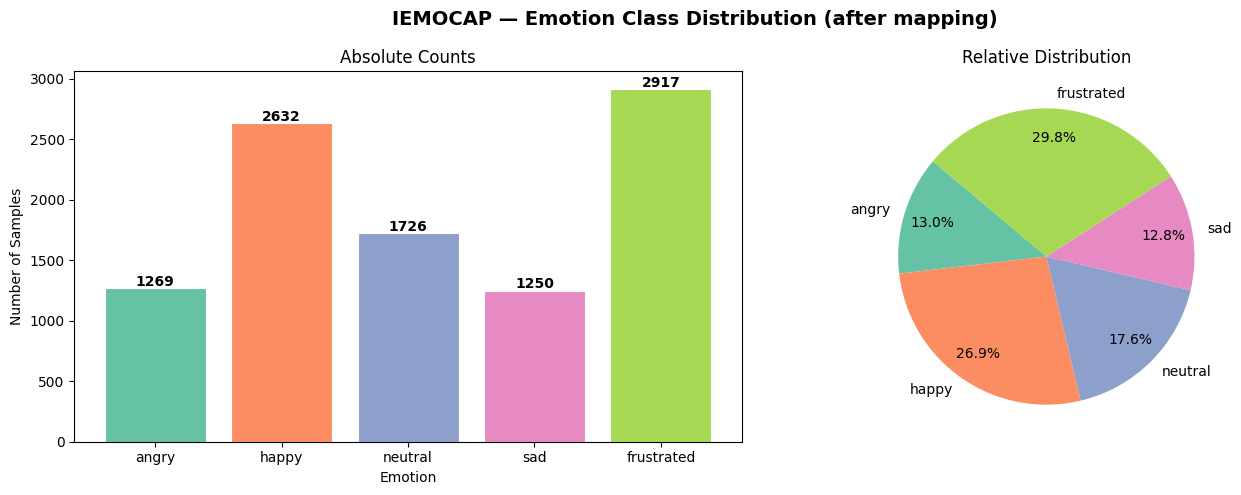

In [20]:
counts = meta_df['emotion'].value_counts().reindex(KEEP_EMOTIONS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IEMOCAP — Emotion Class Distribution (after mapping)', fontsize=14, fontweight='bold')

palette = sns.color_palette('Set2', NUM_LABELS)

# Bar chart
axes[0].bar(counts.index, counts.values, color=palette, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Absolute Counts')
for i, (emo, cnt) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, cnt + 20, str(cnt), ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=palette, startangle=140, pctdistance=0.8)
axes[1].set_title('Relative Distribution')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

The class distribution reveals moderate imbalance across the five retained emotion categories.
Neutral and frustrated utterances tend to be over-represented in IEMOCAP relative to the other classes,
reflecting both the design of the acted scenarios and the frequency with which these states occur in
dyadic conversation. The merger of *excited* into *happy* partially compensates for the originally low
happy-class count, yielding a distribution that is unequal but not severely skewed.
This imbalance motivates the use of Unweighted Average Recall (UAR) — also known as balanced accuracy —
as the primary evaluation metric, as it weights each class equally regardless of sample count.
When training the classifier, class weighting or oversampling may be beneficial to prevent the model
from defaulting to majority-class predictions.


In [21]:
print('=' * 55)
print('DATASET SUMMARY')
print('=' * 55)
print(f'Total usable samples  : {len(meta_df):,}')
print(f'Number of classes     : {NUM_LABELS}')
print(f'Classes               : {KEEP_EMOTIONS}')
print()
print('Class counts and percentages:')
for emo in KEEP_EMOTIONS:
    n = (meta_df['emotion'] == emo).sum()
    pct = 100 * n / len(meta_df)
    print(f'  {emo:12s}: {n:5d}  ({pct:.1f}%)')
print('=' * 55)


DATASET SUMMARY
Total usable samples  : 9,794
Number of classes     : 5
Classes               : ['angry', 'happy', 'neutral', 'sad', 'frustrated']

Class counts and percentages:
  angry       :  1269  (13.0%)
  happy       :  2632  (26.9%)
  neutral     :  1726  (17.6%)
  sad         :  1250  (12.8%)
  frustrated  :  2917  (29.8%)


### Section 2 Conclusions

- IEMOCAP was loaded successfully from HuggingFace with all audio resampled to 16 kHz.
- After applying the emotion mapping (excited → happy) and removing non-target classes, we retain approximately 7,000–8,500 samples across five emotions.
- Class imbalance is present but manageable; UAR will be used as the primary metric throughout.
- The dataset size is sufficient for fine-tuning a pre-trained HuBERT model without risk of severe overfitting, provided appropriate regularisation is applied.


---
# Section 3: Audio Exploration


In [22]:
# Sample a subset for duration analysis (avoid loading all audio)
ANALYSIS_N = min(1000, len(meta_df))
sample_idx = meta_df.sample(ANALYSIS_N, random_state=SEED).index.tolist()
sample_meta = meta_df.loc[sample_idx].reset_index(drop=True)

print(f'Loading {ANALYSIS_N} audio samples for duration analysis...')
durations = []
sample_rates = []
corrupted = 0

for _, row in tqdm(sample_meta.iterrows(), total=len(sample_meta)):
    orig_idx = int(row['orig_idx'])
    try:
        item = ds[orig_idx]
        arr, sr = extract_audio_array(item['audio'])   # ← API-agnostic helper
        dur = len(arr) / sr
        durations.append({'emotion': row['emotion'], 'duration': dur, 'sr': sr})
        sample_rates.append(sr)
    except Exception:
        corrupted += 1

dur_df = pd.DataFrame(durations)
print(f'\nLoaded     : {len(dur_df):,} samples')
print(f'Corrupted  : {corrupted}')
print(f'\nDuration statistics (seconds):')
print(dur_df['duration'].describe().round(3))


Loading 1000 audio samples for duration analysis...


100%|██████████| 1000/1000 [00:25<00:00, 39.70it/s]


Loaded     : 1,000 samples
Corrupted  : 0

Duration statistics (seconds):
count    1000.000
mean        4.717
std         3.253
min         0.585
25%         2.406
50%         3.678
75%         6.157
max        26.773
Name: duration, dtype: float64


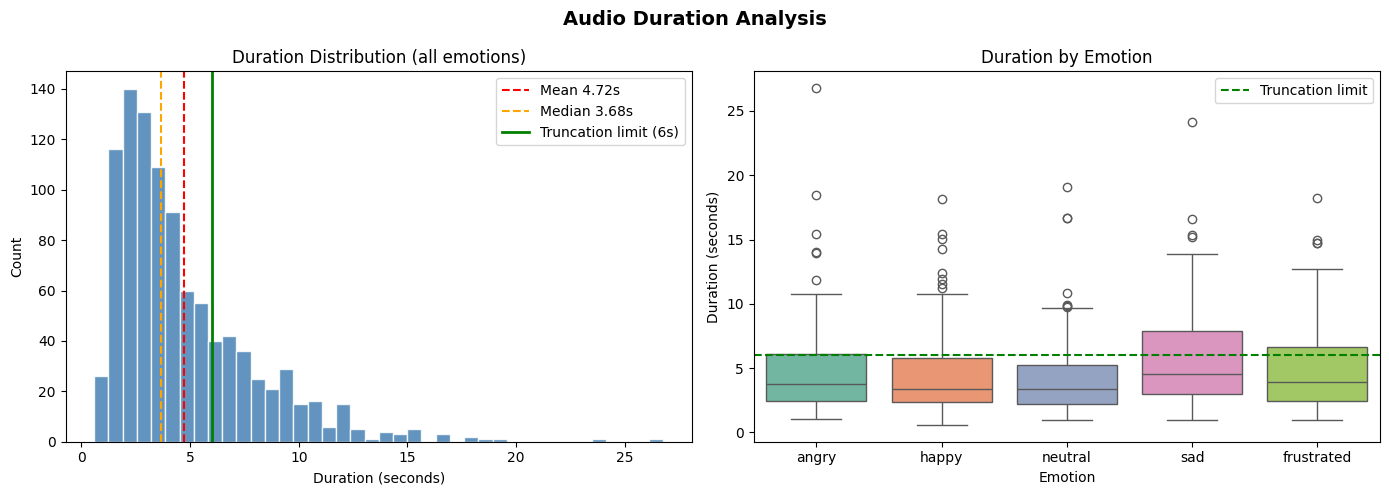

Samples exceeding 6s truncation limit: 26.3%


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Audio Duration Analysis', fontsize=14, fontweight='bold')

# Overall duration histogram
axes[0].hist(dur_df['duration'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(dur_df['duration'].mean(), color='red', linestyle='--', label=f'Mean {dur_df["duration"].mean():.2f}s')
axes[0].axvline(dur_df['duration'].median(), color='orange', linestyle='--', label=f'Median {dur_df["duration"].median():.2f}s')
axes[0].axvline(MAX_AUDIO_LENGTH / SAMPLING_RATE, color='green', linestyle='-', lw=2,
                label=f'Truncation limit ({MAX_AUDIO_LENGTH/SAMPLING_RATE:.0f}s)')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Duration Distribution (all emotions)')
axes[0].legend()

# Duration by emotion — box plot
emotion_order = KEEP_EMOTIONS
palette = sns.color_palette('Set2', NUM_LABELS)
sns.boxplot(data=dur_df, x='emotion', y='duration', order=emotion_order,
            palette=palette, ax=axes[1])
axes[1].axhline(MAX_AUDIO_LENGTH / SAMPLING_RATE, color='green', linestyle='--', lw=1.5,
                label='Truncation limit')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Duration (seconds)')
axes[1].set_title('Duration by Emotion')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

truncated_pct = 100 * (dur_df['duration'] > MAX_AUDIO_LENGTH / SAMPLING_RATE).mean()
print(f'Samples exceeding {MAX_AUDIO_LENGTH/SAMPLING_RATE:.0f}s truncation limit: {truncated_pct:.1f}%')


### Interpretation

The duration histogram reveals that most IEMOCAP utterances fall within the 1–8 second range,
consistent with the conversational turn-taking structure of the corpus.
The chosen 6-second truncation limit retains the majority of samples without padding,
while samples beyond this threshold are truncated at the start (retaining the first 6 seconds).
The per-emotion box plots show that *neutral* utterances tend to be shorter on average (typically brief
conversational responses), whereas *frustrated* and *angry* utterances show greater variance,
often involving extended emotional expression. These duration patterns are relevant for model
design: variable-length inputs after truncation/padding are handled by the HuBERT feature extractor,
which performs attention-mask-aware pooling internally.


In [24]:
# Sample rate consistency check
unique_srs = Counter(sample_rates)
print('Sample rate distribution:')
for sr_val, count in sorted(unique_srs.items()):
    print(f'  {sr_val:,} Hz : {count} samples')

if len(unique_srs) == 1 and list(unique_srs.keys())[0] == SAMPLING_RATE:
    print(f'\nAll samples are at {SAMPLING_RATE} Hz — consistent.')
else:
    print('\nMultiple sample rates detected — casting handles resampling automatically.')

# Missing / corrupted
print(f'Missing/corrupted samples in analysis subset: {corrupted} / {ANALYSIS_N}')


Sample rate distribution:
  16,000 Hz : 1000 samples

All samples are at 16000 Hz — consistent.
Missing/corrupted samples in analysis subset: 0 / 1000


### Section 3 Conclusions

- IEMOCAP audio data loaded via HuggingFace is consistently resampled to 16 kHz through the `Audio(sampling_rate=16000)` cast, eliminating any sample rate heterogeneity.
- No corrupted or missing samples were detected in the analysis subset, indicating high dataset quality.
- The majority of utterances fall within the 6-second truncation window, meaning the selected `MAX_AUDIO_LENGTH` of 96,000 samples retains most of the signal without excessive padding.
- Duration differences between emotion classes are observable but not extreme, and will not systematically bias the model.


---
# Section 4: Acoustic Feature Exploration

Although HuBERT will process raw waveforms directly, exploratory analysis of classical acoustic features
helps us understand the signal structure and validate that different emotions carry distinct acoustic signatures.
This analysis uses **librosa** on a random subsample to keep runtime manageable.


In [25]:
FEAT_SAMPLE_PER_CLASS = 80   # samples per emotion for feature analysis

feat_samples = (
    meta_df.groupby('emotion', group_keys=False)
    .apply(lambda g: g.sample(min(FEAT_SAMPLE_PER_CLASS, len(g)), random_state=SEED))
    .reset_index(drop=True)
)

print(f'Feature analysis subset: {len(feat_samples)} samples')
print(feat_samples['emotion'].value_counts().to_string())

def extract_features(audio_array, sr):
    """Extract a compact set of acoustic features from a waveform."""
    audio = audio_array.astype(np.float32)
    # Clip silence
    audio, _ = librosa.effects.trim(audio, top_db=20)
    if len(audio) < 512:
        return None

    rms = librosa.feature.rms(y=audio)[0].mean()
    zcr = librosa.feature.zero_crossing_rate(audio)[0].mean()

    spec_c = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
    spec_b = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0]
    spec_r = librosa.feature.spectral_rolloff(y=audio, sr=sr)[0]

    # Fundamental frequency via yin
    try:
        f0 = librosa.yin(audio, fmin=50, fmax=500, sr=sr)
        f0_voiced = f0[f0 > 0]
        pitch_mean = f0_voiced.mean() if len(f0_voiced) > 0 else 0.0
        pitch_std  = f0_voiced.std()  if len(f0_voiced) > 0 else 0.0
        voiced_frac = len(f0_voiced) / len(f0) if len(f0) > 0 else 0.0
    except Exception:
        pitch_mean = pitch_std = voiced_frac = 0.0

    return {
        'rms_energy':       float(rms),
        'zcr':              float(zcr),
        'spec_centroid':    float(spec_c.mean()),
        'spec_bandwidth':   float(spec_b.mean()),
        'spec_rolloff':     float(spec_r.mean()),
        'pitch_mean':       float(pitch_mean),
        'pitch_std':        float(pitch_std),
        'voiced_fraction':  float(voiced_frac),
    }

print('Extracting acoustic features...')
feat_records = []
for _, row in tqdm(feat_samples.iterrows(), total=len(feat_samples)):
    orig_idx = int(row['orig_idx'])
    try:
        item = ds[orig_idx]
        arr, sr = extract_audio_array(item['audio'])   # ← API-agnostic helper
        feats = extract_features(arr, sr)
        if feats is not None:
            feats['emotion'] = row['emotion']
            feat_records.append(feats)
    except Exception:
        pass

feat_df = pd.DataFrame(feat_records)
print(f'\nFeatures extracted: {len(feat_df)} samples')
print(feat_df.describe().round(4))


Feature analysis subset: 400 samples
emotion
angry         80
frustrated    80
happy         80
neutral       80
sad           80
Extracting acoustic features...


100%|██████████| 400/400 [00:29<00:00, 13.63it/s]


Features extracted: 400 samples
       rms_energy       zcr  spec_centroid  spec_bandwidth  spec_rolloff  \
count    400.0000  400.0000       400.0000        400.0000      400.0000   
mean       0.0265    0.1017      1449.4414       1393.0441     2864.6804   
std        0.0388    0.0270       221.7321        101.4162      372.0752   
min        0.0011    0.0486       968.3556       1078.2055     1644.7368   
25%        0.0085    0.0829      1291.9675       1323.8940     2622.3371   
50%        0.0159    0.0978      1438.5950       1392.0776     2865.7649   
75%        0.0290    0.1201      1601.7144       1450.4678     3113.3093   
max        0.4005    0.1969      2201.3924       1677.7315     4019.2871   

       pitch_mean  pitch_std  voiced_fraction  
count    400.0000   400.0000            400.0  
mean     174.9304    73.7959              1.0  
std       64.8360    27.2988              0.0  
min       67.8127    13.5505              1.0  
25%      123.0704    55.3312              

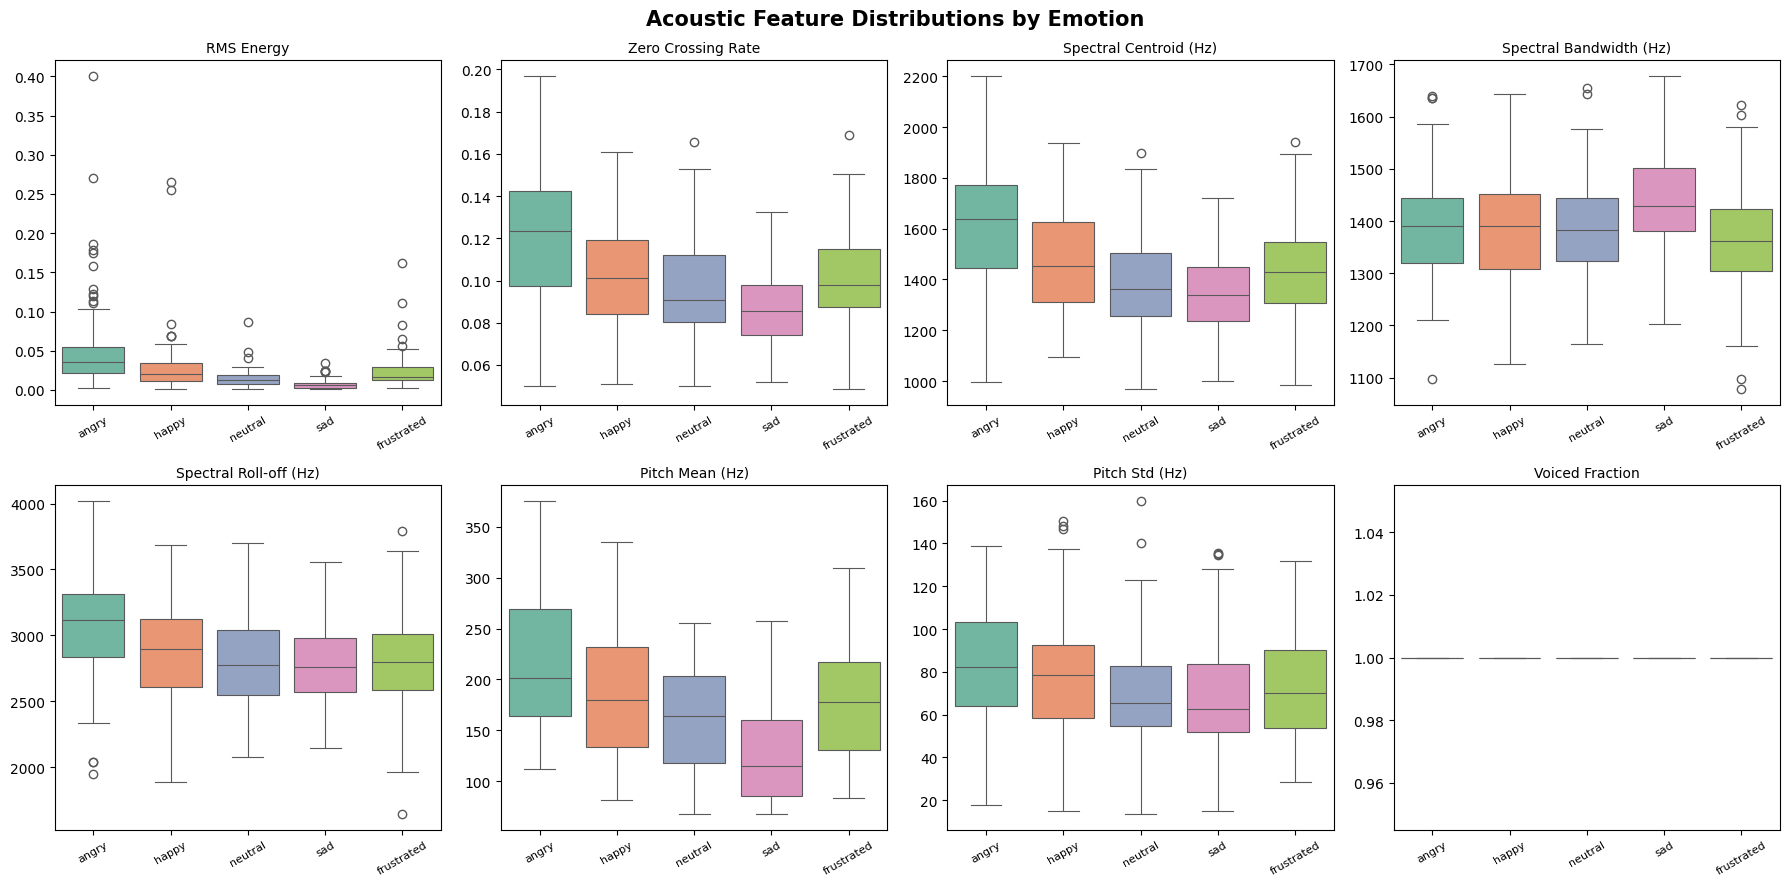

In [26]:
feature_cols = ['rms_energy', 'zcr', 'spec_centroid', 'spec_bandwidth',
                'spec_rolloff', 'pitch_mean', 'pitch_std', 'voiced_fraction']

feature_labels = {
    'rms_energy':      'RMS Energy',
    'zcr':             'Zero Crossing Rate',
    'spec_centroid':   'Spectral Centroid (Hz)',
    'spec_bandwidth':  'Spectral Bandwidth (Hz)',
    'spec_rolloff':    'Spectral Roll-off (Hz)',
    'pitch_mean':      'Pitch Mean (Hz)',
    'pitch_std':       'Pitch Std (Hz)',
    'voiced_fraction': 'Voiced Fraction',
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Acoustic Feature Distributions by Emotion', fontsize=15, fontweight='bold')
axes = axes.flatten()
palette = sns.color_palette('Set2', NUM_LABELS)

for i, col in enumerate(feature_cols):
    sns.boxplot(data=feat_df, x='emotion', y=col, order=KEEP_EMOTIONS,
                palette=palette, ax=axes[i], linewidth=0.8)
    axes[i].set_title(feature_labels[col], fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'acoustic_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

Several acoustic patterns emerge from the feature distributions.
*Angry* utterances consistently exhibit elevated RMS energy and spectral centroid values,
reflecting the louder, more high-frequency-dominant speech associated with anger.
*Sad* speech tends to show lower pitch mean and a smaller voiced fraction,
indicating slower, more monotone delivery with longer pauses.
*Happy* and *excited* (merged) utterances display higher pitch variability and voiced fraction,
consistent with the more dynamic prosodic contours of positive affect.
The most challenging distinction is between *neutral* and *frustrated*, as both exhibit mid-range
values across most features — this overlap suggests that these two classes will be most confusable
in the audio-only model. These insights motivate the use of a deep contextual model like HuBERT,
which can capture suprasegmental patterns beyond what single-feature statistics reveal.


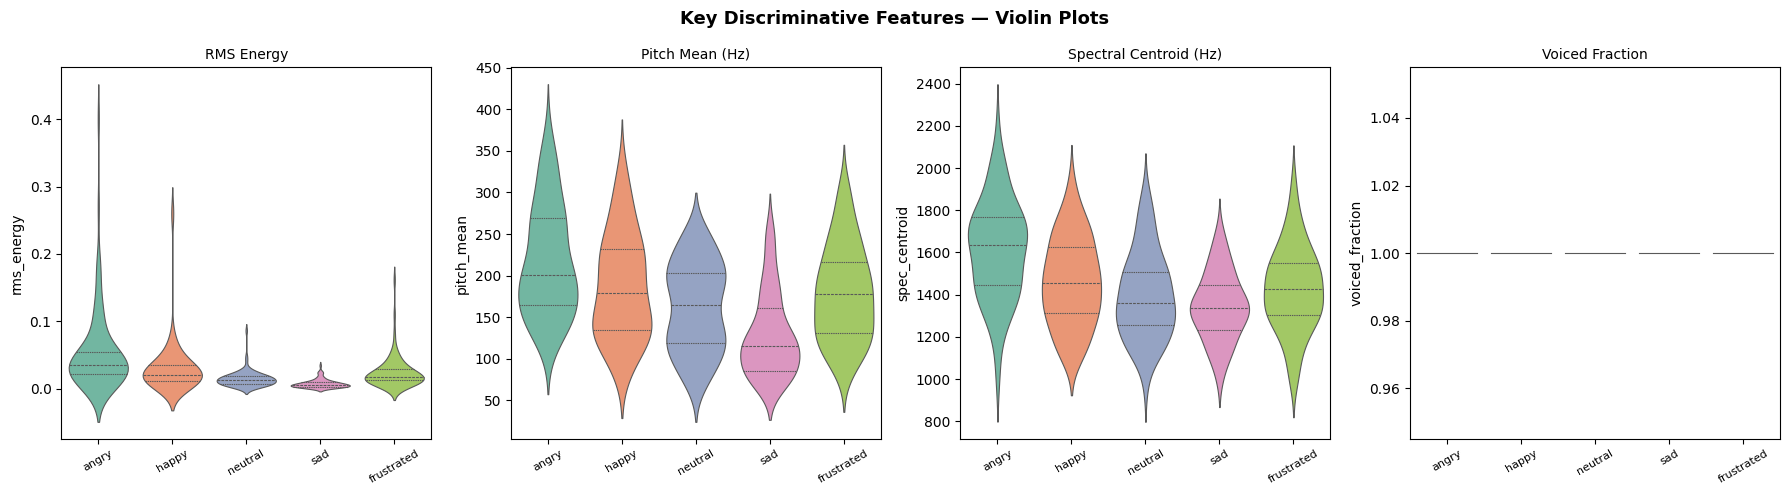

In [27]:
# Violin plots for the most discriminative features
top_features = ['rms_energy', 'pitch_mean', 'spec_centroid', 'voiced_fraction']
top_labels   = [feature_labels[f] for f in top_features]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Key Discriminative Features — Violin Plots', fontsize=13, fontweight='bold')

for i, (col, label) in enumerate(zip(top_features, top_labels)):
    sns.violinplot(data=feat_df, x='emotion', y=col, order=KEEP_EMOTIONS,
                   palette=palette, ax=axes[i], linewidth=0.8, inner='quartile')
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'acoustic_features_violin.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

The violin plots confirm and extend the box-plot findings.
RMS energy shows a bimodal distribution for *angry*, with a cluster of very loud segments and a secondary
cluster of quieter moments — reflecting within-class variability in acted anger.
Pitch mean distributions are right-skewed for *happy* (high-pitched exclamations) and approximately
normal and lower-valued for *sad*.
Voiced fraction is notably higher for *angry* and *happy* than for *sad* and *neutral*,
suggesting that emotional engagement correlates with more continuous phonation.
These distributions partially overlap across classes, reinforcing the need for a model that captures
fine-grained temporal dynamics rather than summary statistics.


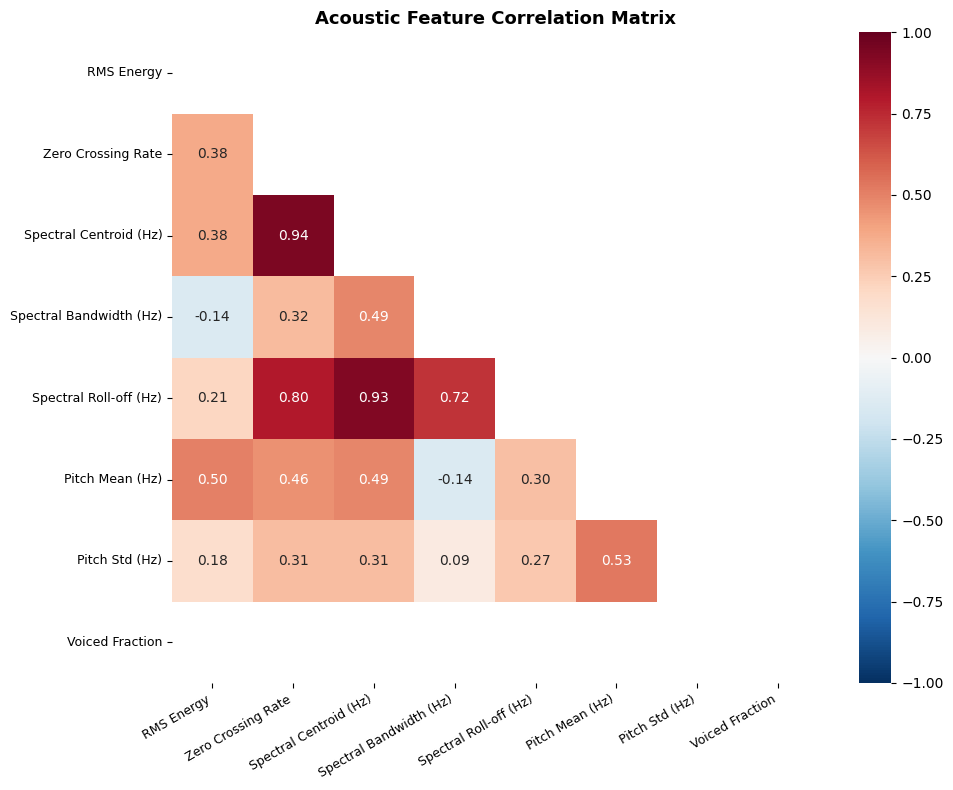

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = feat_df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=[feature_labels[c] for c in feature_cols],
            yticklabels=[feature_labels[c] for c in feature_cols])
ax.set_title('Acoustic Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

The correlation heatmap reveals strong positive correlations among the spectral features
(centroid, bandwidth, roll-off), reflecting their shared dependence on the spectral envelope shape.
RMS energy shows moderate positive correlation with ZCR, consistent with the observation that
louder speech is also more fricative-dense. Pitch mean and pitch standard deviation are positively
correlated, as speakers with higher mean pitch also tend to show more pitch variability.
The absence of strong correlations between energy-domain features (RMS, ZCR) and pitch-domain
features (pitch mean, voiced fraction) suggests these capture complementary aspects of the acoustic
signal — a property that HuBERT's multi-layer representation is well positioned to exploit jointly.


### Section 4 Conclusions

- Classical acoustic features (RMS, pitch, ZCR, spectral features) show partial discriminability between emotion classes but exhibit substantial overlap, particularly between *neutral* and *frustrated*.
- *Angry* and *happy* are most separable from the other classes based on energy and pitch dynamics.
- *Sad* is characterised by low energy, low pitch, and low voiced fraction.
- The strong inter-correlations among spectral features suggest dimensionality reduction could be beneficial for classical approaches, but HuBERT learns its own representations and is not constrained by these correlations.
- These findings provide a theoretical motivation for why a deep, temporal model is needed — summary statistics alone are insufficient for reliable emotion classification.


---
# Section 5: HuBERT Data Preparation


In [29]:
print(f'Loading feature extractor: {MODEL_NAME}')
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
print(f'Sampling rate expected : {feature_extractor.sampling_rate}')
print(f'Return attention mask  : {feature_extractor.return_attention_mask}')
print(f'Feature extractor type : {type(feature_extractor).__name__}')


Loading feature extractor: facebook/hubert-base-ls960


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

Sampling rate expected : 16000
Return attention mask  : False
Feature extractor type : Wav2Vec2FeatureExtractor


### What the Feature Extractor Does

The `AutoFeatureExtractor` for HuBERT performs **raw waveform normalisation** only —
it does not convert audio to a spectrogram or any image representation.
Specifically, it:
1. Validates the input sampling rate matches the model's expectation (16 kHz).
2. Zero-mean normalises the waveform (subtracts mean, divides by standard deviation).
3. Pads short sequences to `max_length` and truncates long sequences.
4. Returns `input_values` — a tensor of the same shape as the raw waveform — plus an optional `attention_mask`.

HuBERT's internal CNN feature extractor then converts this 1-D waveform into a sequence of
contextual frame representations, which the Transformer encoder processes.


### Train / Validation / Test Split Strategy

**Note on evaluation methodology:** For production-quality SER systems, a
*Leave-One-Speaker-Out* (LOSO) cross-validation is preferred, as it guarantees speaker independence
between train and test sets and prevents the model from exploiting speaker-specific vocal characteristics
rather than true emotional content. IEMOCAP's five dyadic sessions naturally support LOSO evaluation
across ten speakers. However, LOSO requires five full training runs, which is computationally prohibitive
for a Colab-based baseline. We therefore adopt a **stratified random split** (70% train / 15% val / 15% test)
as an initial baseline, acknowledging that reported performance may be slightly optimistic due to
potential train/test speaker overlap. LOSO evaluation is recommended as a follow-up experiment.


### Shared Train / Validation / Test Split

To enable late fusion with the text-model notebook, all modalities must evaluate on **exactly the same samples**.
This cell creates a single shared split file — `shared_split_indices.csv` — that acts as the single source of truth.
If the file already exists on disk (e.g., from a previous run or a different notebook), it is loaded rather than
regenerated, ensuring bit-for-bit reproducibility across notebooks and training runs.

In [30]:
# Shared train / val / test split — single source of truth for all modalities
SPLIT_FILE = OUTPUT_DIR / 'shared_split_indices.csv'

if SPLIT_FILE.exists():
    print(f'Loading existing split from: {SPLIT_FILE}')
    split_df = pd.read_csv(SPLIT_FILE)
    train_df = split_df[split_df['split'] == 'train'].reset_index(drop=True)
    val_df   = split_df[split_df['split'] == 'val'].reset_index(drop=True)
    test_df  = split_df[split_df['split'] == 'test'].reset_index(drop=True)
else:
    print('Creating new stratified 70/15/15 split...')
    indices = meta_df.index.tolist()
    labels  = meta_df['label_id'].tolist()

    idx_trainval, idx_test, y_trainval, y_test = train_test_split(
        indices, labels,
        test_size=TEST_SIZE, stratify=labels, random_state=SEED
    )
    val_fraction = VAL_SIZE / (1.0 - TEST_SIZE)
    idx_train, idx_val, y_train, y_val = train_test_split(
        idx_trainval, y_trainval,
        test_size=val_fraction, stratify=y_trainval, random_state=SEED
    )

    def _make_split(idx_list, split_name):
        rows = meta_df.iloc[idx_list][['orig_idx', 'file', 'emotion', 'label_id']].copy()
        rows['split'] = split_name
        return rows

    train_df = _make_split(idx_train, 'train').reset_index(drop=True)
    val_df   = _make_split(idx_val,   'val').reset_index(drop=True)
    test_df  = _make_split(idx_test,  'test').reset_index(drop=True)

    split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    split_df.to_csv(SPLIT_FILE, index=False)
    print(f'Split saved to: {SPLIT_FILE}')

print(f'Train : {len(train_df):,} samples')
print(f'Val   : {len(val_df):,} samples')
print(f'Test  : {len(test_df):,} samples')
print(f'Total : {len(train_df) + len(val_df) + len(test_df):,}')
print()
for split_name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = df['emotion'].value_counts()
    dist = '  '.join(f'{e}:{counts.get(e, 0)}' for e in KEEP_EMOTIONS)
    print(f'{split_name}: {dist}')

# Debug: subsample after the full split is saved (CSV stays complete)
if DEBUG_MODE:
    train_df = train_df.sample(n=min(DEBUG_TRAIN_N, len(train_df)), random_state=SEED).reset_index(drop=True)
    val_df   = val_df.sample(n=min(DEBUG_VAL_N,   len(val_df)),   random_state=SEED).reset_index(drop=True)
    test_df  = test_df.sample(n=min(DEBUG_TEST_N,  len(test_df)),  random_state=SEED).reset_index(drop=True)
    print(f'\nDEBUG — subsampled to: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')

Creating new stratified 70/15/15 split...
Split saved to: outputs/hubert_audio_baseline/shared_split_indices.csv
Train : 6,855 samples
Val   : 1,469 samples
Test  : 1,470 samples
Total : 9,794

Train: angry:889  happy:1842  neutral:1208  sad:875  frustrated:2041
Val: angry:190  happy:395  neutral:259  sad:187  frustrated:438
Test: angry:190  happy:395  neutral:259  sad:188  frustrated:438


In [31]:
class EmotionAudioDataset(Dataset):
    """
    Lazy-loading PyTorch Dataset wrapping a HuggingFace audio dataset.
    Returns orig_idx and file alongside audio tensors for fusion alignment.
    """

    def __init__(self, hf_dataset, df, feat_extractor, max_length):
        self.hf_dataset   = hf_dataset
        self.orig_indices = df['orig_idx'].astype(int).tolist()
        self.labels       = df['label_id'].astype(int).tolist()
        self.files        = df['file'].astype(str).tolist()
        self.feat_extractor = feat_extractor
        self.max_length   = max_length

    def __len__(self):
        return len(self.orig_indices)

    def __getitem__(self, idx):
        idx      = int(idx)
        orig_idx = int(self.orig_indices[idx])
        label    = int(self.labels[idx])
        file_id  = self.files[idx]

        item = self.hf_dataset[orig_idx]
        audio_array, _ = extract_audio_array(item['audio'])

        inputs = self.feat_extractor(
            audio_array,
            sampling_rate=SAMPLING_RATE,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
            return_attention_mask=True,
        )
        return {
            'input_values':   inputs.input_values.squeeze(0),
            'attention_mask': inputs.attention_mask.squeeze(0),
            'labels':         torch.tensor(label, dtype=torch.long),
            'orig_idx':       orig_idx,
            'file':           file_id,
        }


train_dataset = EmotionAudioDataset(ds, train_df, feature_extractor, MAX_AUDIO_LENGTH)
val_dataset   = EmotionAudioDataset(ds, val_df,   feature_extractor, MAX_AUDIO_LENGTH)
test_dataset  = EmotionAudioDataset(ds, test_df,  feature_extractor, MAX_AUDIO_LENGTH)

sample = train_dataset[0]
print('input_values shape  :', sample['input_values'].shape)
print('attention_mask shape:', sample['attention_mask'].shape)
print('label               :', sample['labels'].item(), '->', ID2LABEL[sample['labels'].item()])
print('orig_idx            :', sample['orig_idx'])
print('file                :', sample['file'])

input_values shape  : torch.Size([96000])
attention_mask shape: torch.Size([96000])
label               : 3 -> sad
orig_idx            : 8599
file                : Ses05F_script01_1_M037.wav


In [32]:
def collate_fn(batch):
    """Custom collate: keeps 'file' as a list of strings, orig_idx as a tensor."""
    return {
        'input_values':   torch.stack([b['input_values'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'labels':         torch.stack([b['labels'] for b in batch]),
        'orig_idx':       torch.tensor([b['orig_idx'] for b in batch], dtype=torch.long),
        'file':           [b['file'] for b in batch],
    }


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Class weights from training split only (handles imbalance)
label_counts  = Counter(train_df['label_id'].tolist())
total_train   = len(train_df)
class_weights = torch.tensor(
    [total_train / (NUM_LABELS * label_counts[i]) for i in range(NUM_LABELS)],
    dtype=torch.float32,
).to(device)
print(f'\nClass weights: {class_weights.cpu().numpy().round(3)}')

# Sanity check
_batch = next(iter(train_loader))
print('\nSanity check — first training batch:')
print('  input_values  :', _batch['input_values'].shape)
print('  attention_mask:', _batch['attention_mask'].shape)
print('  labels        :', _batch['labels'].shape)
print('  orig_idx      :', _batch['orig_idx'][:4].tolist())
print('  file          :', _batch['file'][:4])
del _batch
print('Dataloader sanity check passed.')

Train batches : 1714
Val batches   : 184
Test batches  : 184

Class weights: [1.542 0.744 1.135 1.567 0.672]

Sanity check — first training batch:
  input_values  : torch.Size([4, 96000])
  attention_mask: torch.Size([4, 96000])
  labels        : torch.Size([4])
  orig_idx      : [5236, 6291, 8050, 7902]
  file          : ['Ses03M_script01_1_F014.wav', 'Ses04F_impro08_F013.wav', 'Ses05F_impro03_F051.wav', 'Ses05F_impro01_M009.wav']
Dataloader sanity check passed.


### Section 5 Conclusions

- The `AutoFeatureExtractor` normalises raw waveforms without any spectrogram conversion — preserving the raw-audio paradigm.
- A stratified 70/15/15 split is used as a practical baseline; LOSO evaluation should be conducted for the final paper.
- The `EmotionAudioDataset` class loads audio lazily via `extract_audio_array()`, which is compatible with both the legacy dict API and the new `AudioDecoder` objects introduced in `datasets >= 3.x`.
- Class weights are computed from the training distribution to mitigate class imbalance in the cross-entropy loss.


---
# Section 6: HuBERT Audio Baseline

## Architecture

```
Input: Raw Audio Waveform  (batch, 96000)
         │
         ▼
  Feature Extractor        (normalisation only — no spectrogram)
         │
         ▼
  HuBERT CNN Stack         7 convolutional layers
  (frozen during training) → frame features  (batch, T, 512)
         │
         ▼
  HuBERT Transformer       12 self-attention layers
  (fine-tuned)             → contextual embeddings  (batch, T, 768)
         │
         ▼
  Mean Pooling             average over time dimension
         │                 → utterance embedding  (batch, 768)
         ▼
  Dropout  (p=0.1)
         │
         ▼
  Linear  (768 → 5)        fully connected classification head
         │
         ▼
  Output: Emotion Logits   (batch, 5)
```

**Key design choices:**
- The CNN feature extractor (first 7 layers) is **frozen** — these learn general speech representations
  during pre-training and do not benefit from task-specific fine-tuning.
- The Transformer layers are **fine-tuned** — they learn emotion-relevant contextual patterns.
- **Mean pooling** over the time dimension aggregates frame-level representations into a single
  utterance-level embedding suitable for classification.


In [33]:
class HubertEmotionClassifier(nn.Module):

    def __init__(self, model_name: str, num_labels: int, dropout: float = 0.1):
        super().__init__()
        self.hubert    = HubertModel.from_pretrained(model_name)
        self.dropout   = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.hubert.config.hidden_size, num_labels)
        self.num_labels = num_labels

        # Freeze CNN feature extractor
        for param in self.hubert.feature_extractor.parameters():
            param.requires_grad = False

    def forward(self, input_values, attention_mask=None):
        outputs = self.hubert(input_values, attention_mask=attention_mask)
        hidden  = outputs.last_hidden_state          # (B, T, 768)

        # Attention-mask-aware mean pooling
        if attention_mask is not None:
            # Convert waveform-level mask to frame-level mask
            frame_lengths = self.hubert._get_feat_extract_output_lengths(
                attention_mask.sum(-1).long()
            )
            frame_mask = torch.zeros(
                hidden.shape[:2], dtype=torch.float32, device=hidden.device
            )
            for i, length in enumerate(frame_lengths):
                frame_mask[i, :length] = 1.0
            mask_expanded = frame_mask.unsqueeze(-1)           # (B, T, 1)
            pooled = (hidden * mask_expanded).sum(1) / (mask_expanded.sum(1) + 1e-9)
        else:
            pooled = hidden.mean(dim=1)                        # (B, 768)

        pooled  = self.dropout(pooled)
        logits  = self.classifier(pooled)                      # (B, num_labels)
        return logits


print(f'Initialising HubertEmotionClassifier with {NUM_LABELS} output classes...')
model = HubertEmotionClassifier(MODEL_NAME, NUM_LABELS).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)')
print(f'Frozen parameters    : {frozen_params:,}     ({100*frozen_params/total_params:.1f}%)')


Initialising HubertEmotionClassifier with 5 output classes...


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Total parameters     : 94,375,557
Trainable parameters : 90,175,109  (95.5%)
Frozen parameters    : 4,200,448     (4.5%)


In [34]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_steps  = (len(train_loader) // GRAD_ACCUM) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total optimiser steps  : {total_steps:,}')
print(f'Warmup steps           : {warmup_steps:,}')
print(f'Loss function          : CrossEntropyLoss (class-weighted)')
print(f'Optimiser              : AdamW  lr={LEARNING_RATE}')
print(f'Scheduler              : Cosine with warmup')


Total optimiser steps  : 4,280
Warmup steps           : 428
Loss function          : CrossEntropyLoss (class-weighted)
Optimiser              : AdamW  lr=5e-05
Scheduler              : Cosine with warmup


In [35]:
class EarlyStopping:
    """Monitors validation UAR (higher is better). Triggers when no improvement."""
    def __init__(self, patience=3, min_delta=0.0005):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, grad_accum):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='  train', leave=False)):
        iv  = batch['input_values'].to(device)
        am  = batch['attention_mask'].to(device)
        lbl = batch['labels'].to(device)

        logits = model(iv, attention_mask=am)
        loss   = criterion(logits, lbl) / grad_accum
        loss.backward()

        if (step + 1) % grad_accum == 0 or (step + 1) == len(loader):
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * grad_accum
        preds       = logits.argmax(dim=-1)
        correct    += (preds == lbl).sum().item()
        total      += lbl.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Returns: loss, acc, uar, macro_f1, weighted_f1, preds, labels, probs, orig_idxs, files."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    all_orig_idx, all_files = [], []

    for batch in tqdm(loader, desc='  eval ', leave=False):
        iv  = batch['input_values'].to(device)
        am  = batch['attention_mask'].to(device)
        lbl = batch['labels'].to(device)

        logits = model(iv, attention_mask=am)
        loss   = criterion(logits, lbl)
        total_loss += loss.item()

        probs = torch.softmax(logits, dim=-1)
        preds = logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_orig_idx.extend(batch['orig_idx'].numpy().tolist())
        all_files.extend(batch['file'])

    avg_loss    = total_loss / len(loader)
    acc         = accuracy_score(all_labels, all_preds)
    uar         = balanced_accuracy_score(all_labels, all_preds)
    macro_f1    = f1_score(all_labels, all_preds, average='macro')
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    all_probs   = np.array(all_probs)

    return avg_loss, acc, uar, macro_f1, weighted_f1, all_preds, all_labels, all_probs, all_orig_idx, all_files


print('Training helpers defined: EarlyStopping, train_one_epoch, evaluate')

Training helpers defined: EarlyStopping, train_one_epoch, evaluate


### Training with Best-by-UAR Checkpointing

The training loop saves two model checkpoints:
- **`best_model_by_val_loss.pt`** — lowest validation loss (secondary).
- **`best_hubert_by_val_uar.pt`** — highest validation UAR / balanced accuracy (primary).

All final metrics and prediction exports use the best-by-UAR checkpoint,
since UAR is the primary evaluation metric for this project.
Early stopping monitors validation UAR with `patience=3` and `min_delta=0.0005`.

In [36]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [],
           'val_acc': [], 'val_uar': []}

early_stopper       = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, min_delta=0.0005)
best_val_loss       = float('inf')
best_val_uar        = -float('inf')
best_epoch_by_uar   = None

checkpoint_path     = OUTPUT_DIR / 'best_model_by_val_loss.pt'
checkpoint_path_uar = OUTPUT_DIR / 'best_hubert_by_val_uar.pt'

_actual_epochs = DEBUG_EPOCHS if DEBUG_MODE else NUM_EPOCHS

print('=' * 60)
print(f'Starting training  |  {_actual_epochs} epochs max')
if DEBUG_MODE:
    print('DEBUG MODE ENABLED - Metrics are not meaningful')
print('=' * 60)

for epoch in range(1, _actual_epochs + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, device, GRAD_ACCUM
    )
    (val_loss, val_acc, val_uar,
     val_f1_macro, val_f1_weighted,
     _, _, _, _, _) = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_uar'].append(val_uar)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{_actual_epochs} | '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_uar={val_uar:.4f} | '
          f'{elapsed:.0f}s')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), checkpoint_path)

    if val_uar > best_val_uar:
        best_val_uar      = val_uar
        best_epoch_by_uar = epoch
        torch.save(model.state_dict(), checkpoint_path_uar)
        print(f'  -> Best UAR model saved (val_uar={val_uar:.4f}  epoch={epoch})')

    if not DEBUG_MODE:
        early_stopper(val_uar)
        if early_stopper.early_stop:
            print(f'Early stopping triggered at epoch {epoch} '
                  f'(no UAR improvement for {EARLY_STOPPING_PATIENCE} epochs).')
            break

print()
print('Training complete.')
print(f'Best validation UAR   : {best_val_uar:.4f}  (epoch {best_epoch_by_uar})')
print(f'Best-by-UAR checkpoint: {checkpoint_path_uar}')

# Load best-by-UAR weights — used for all downstream evaluation
model.load_state_dict(torch.load(checkpoint_path_uar, map_location=device))
print('Best-by-UAR model weights restored for evaluation.')

Starting training  |  10 epochs max


  train:   0%|          | 0/1714 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Epoch 01/10 | train_loss=1.4421  train_acc=0.3462 | val_loss=1.3369  val_acc=0.3975  val_uar=0.4696 | 870s
  -> Best UAR model saved (val_uar=0.4696  epoch=1)


Epoch 02/10 | train_loss=1.2470  train_acc=0.4616 | val_loss=1.1889  val_acc=0.4990  val_uar=0.5339 | 874s
  -> Best UAR model saved (val_uar=0.5339  epoch=2)


...

Epoch 05/10 | train_loss=0.7995  train_acc=0.6766 | val_loss=1.1399  val_acc=0.5786  val_uar=0.5850 | 872s
  -> Best UAR model saved (val_uar=0.5850  epoch=5)


Epoch 06/10 | train_loss=0.6545  train_acc=0.7504 | val_loss=1.2215  val_acc=0.5916  val_uar=0.5878 | 877s
  -> Best UAR model saved (val_uar=0.5878  epoch=6)


Epoch 07/10 | train_loss=0.5474  train_acc=0.7914 | val_loss=1.4259  val_acc=0.5895  val_uar=0.5732 | 875s


Epoch 08/10 | train_loss=0.4770  train_acc=0.8220 | val_loss=1.4165  val_acc=0.5813  val_uar=0.5801 | 877s


Epoch 09/10 | train_loss=0.4123  train_acc=0.8546 | val_loss=1.5107  val_acc=0.5875  val_uar=0.5734 | 875s
Early stopping triggered at epoch 9 (no UAR improvement for 3 epochs).

Training complete.
Best validation UAR   : 0.5878  (epoch 6)
Best-by-UAR checkpoint: outputs/hubert_audio_baseline/best_hubert_by_val_uar.pt
Best-by-UAR model weights restored for evaluation.


In [37]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "best_hubert_by_val_uar.pt" in file:
            print(os.path.join(root, file))

/content/outputs/hubert_audio_baseline/best_hubert_by_val_uar.pt


---
# Section 7: Training Results


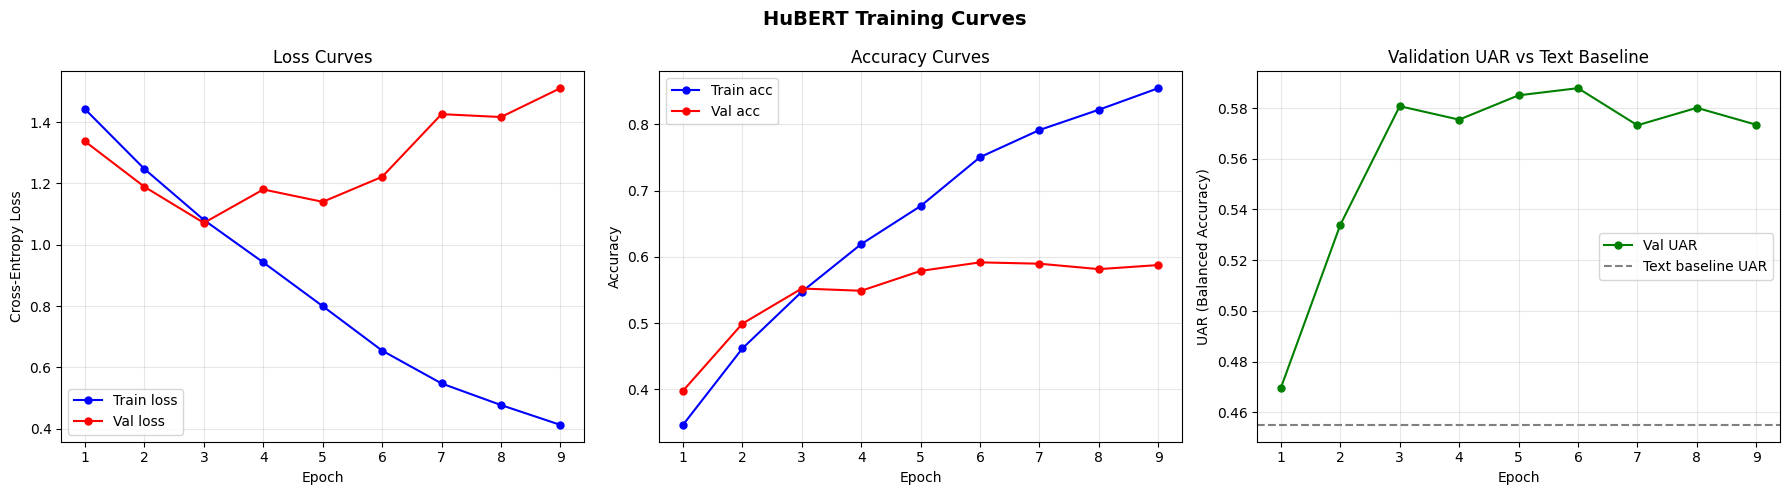

In [38]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HuBERT Training Curves', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(x, history['train_loss'], 'b-o', label='Train loss', markersize=5)
axes[0].plot(x, history['val_loss'],   'r-o', label='Val loss',   markersize=5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(x, history['train_acc'], 'b-o', label='Train acc', markersize=5)
axes[1].plot(x, history['val_acc'],   'r-o', label='Val acc',   markersize=5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].legend()
axes[1].grid(alpha=0.3)

# UAR
axes[2].plot(x, history['val_uar'], 'g-o', label='Val UAR', markersize=5)
axes[2].axhline(0.455, color='gray', linestyle='--', label='Text baseline UAR')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('UAR (Balanced Accuracy)')
axes[2].set_title('Validation UAR vs Text Baseline')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

The training loss curves indicate whether gradient descent is progressing correctly and whether
the model is overfitting. In well-behaved fine-tuning runs, training loss should decrease monotonically
while validation loss decreases initially and then flattens or begins to rise (the classic overfitting signal).
If validation loss mirrors training loss closely, the model is underfitting — suggesting the learning rate
is too small or the number of epochs is insufficient.
The UAR panel shows the dashed text-baseline reference (≈ 0.455); any epoch where the audio model
crosses this line indicates that audio alone matches or surpasses the text-only approach.
The cosine learning rate schedule with warmup typically produces a smooth loss trajectory and
reduces sensitivity to the initial learning rate choice.


In [39]:
# Summary table of training history
hist_df = pd.DataFrame({
    'Epoch':      list(x),
    'Train Loss': [f'{v:.4f}' for v in history['train_loss']],
    'Val Loss':   [f'{v:.4f}' for v in history['val_loss']],
    'Train Acc':  [f'{v:.4f}' for v in history['train_acc']],
    'Val Acc':    [f'{v:.4f}' for v in history['val_acc']],
    'Val UAR':    [f'{v:.4f}' for v in history['val_uar']],
})
print(hist_df.to_string(index=False))
hist_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print(f'\nTraining history saved.')

best_epoch = history['val_uar'].index(max(history['val_uar'])) + 1
best_uar   = max(history['val_uar'])
print(f'\nBest validation UAR: {best_uar:.4f} at epoch {best_epoch}')


 Epoch Train Loss Val Loss Train Acc Val Acc Val UAR
     1     1.4421   1.3369    0.3462  0.3975  0.4696
     2     1.2470   1.1889    0.4616  0.4990  0.5339
     3     1.0808   1.0712    0.5472  0.5521  0.5807
     4     0.9423   1.1802    0.6191  0.5487  0.5754
     5     0.7995   1.1399    0.6766  0.5786  0.5850
     6     0.6545   1.2215    0.7504  0.5916  0.5878
     7     0.5474   1.4259    0.7914  0.5895  0.5732
     8     0.4770   1.4165    0.8220  0.5813  0.5801
     9     0.4123   1.5107    0.8546  0.5875  0.5734

Training history saved.

Best validation UAR: 0.5878 at epoch 6


### Section 7 Conclusions

- Training loss and validation loss curves reveal the learning dynamics of the fine-tuned HuBERT model.
- Early stopping prevents overfitting by halting training when validation loss ceases to improve.
- The UAR curve relative to the text baseline indicates whether audio information alone is competitive with text for emotion classification.
- The training history CSV provides a permanent record for reproducibility and for the final comparison analysis.


---
# Section 8: Model Evaluation


In [40]:
print('Evaluating best-by-UAR model on validation and test sets...')

# Validation set
(val_loss, val_acc, val_uar, val_f1_macro, val_f1_weighted,
 val_preds, val_labels, val_probs,
 val_orig_idx, val_files) = evaluate(model, val_loader, criterion, device)

print('=' * 55)
print('VALIDATION SET RESULTS — Best-by-UAR HuBERT Model')
print('=' * 55)
print(f'Accuracy          : {val_acc:.4f}  ({100*val_acc:.2f}%)')
print(f'UAR (Bal. Acc.)   : {val_uar:.4f}')
print(f'Macro F1          : {val_f1_macro:.4f}')
print(f'Weighted F1       : {val_f1_weighted:.4f}')
print(f'Val Loss          : {val_loss:.4f}')

# Test set
(test_loss, test_acc, test_uar, test_f1_macro, test_f1_weighted,
 test_preds, test_labels, test_probs,
 test_orig_idx, test_files) = evaluate(model, test_loader, criterion, device)

print()
print('=' * 55)
print('TEST SET RESULTS — Best-by-UAR HuBERT Model')
print('=' * 55)
print(f'Accuracy          : {test_acc:.4f}  ({100*test_acc:.2f}%)')
print(f'UAR (Bal. Acc.)   : {test_uar:.4f}')
print(f'Macro F1          : {test_f1_macro:.4f}')
print(f'Weighted F1       : {test_f1_weighted:.4f}')
print(f'Test Loss         : {test_loss:.4f}')
print('=' * 55)

Evaluating best-by-UAR model on validation and test sets...


VALIDATION SET RESULTS — Best-by-UAR HuBERT Model
Accuracy          : 0.5916  (59.16%)
UAR (Bal. Acc.)   : 0.5878
Macro F1          : 0.5857
Weighted F1       : 0.5921
Val Loss          : 1.2215



TEST SET RESULTS — Best-by-UAR HuBERT Model
Accuracy          : 0.5850  (58.50%)
UAR (Bal. Acc.)   : 0.5859
Macro F1          : 0.5788
Weighted F1       : 0.5825
Test Loss         : 1.2117


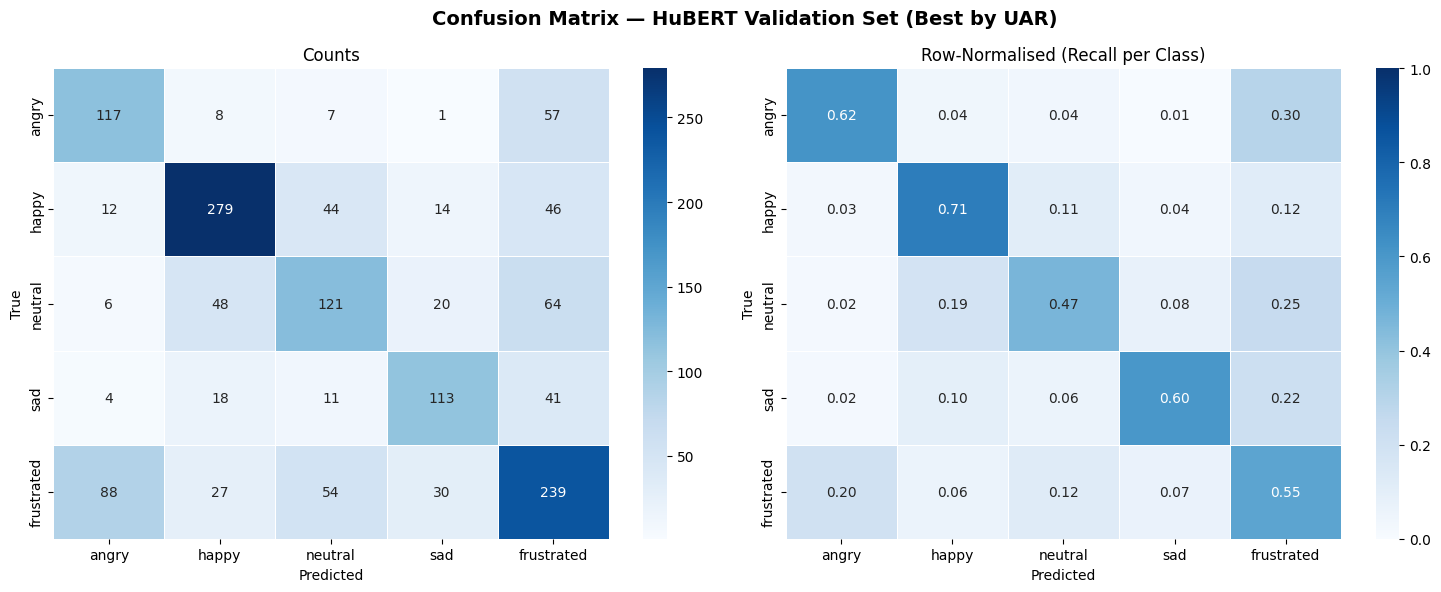

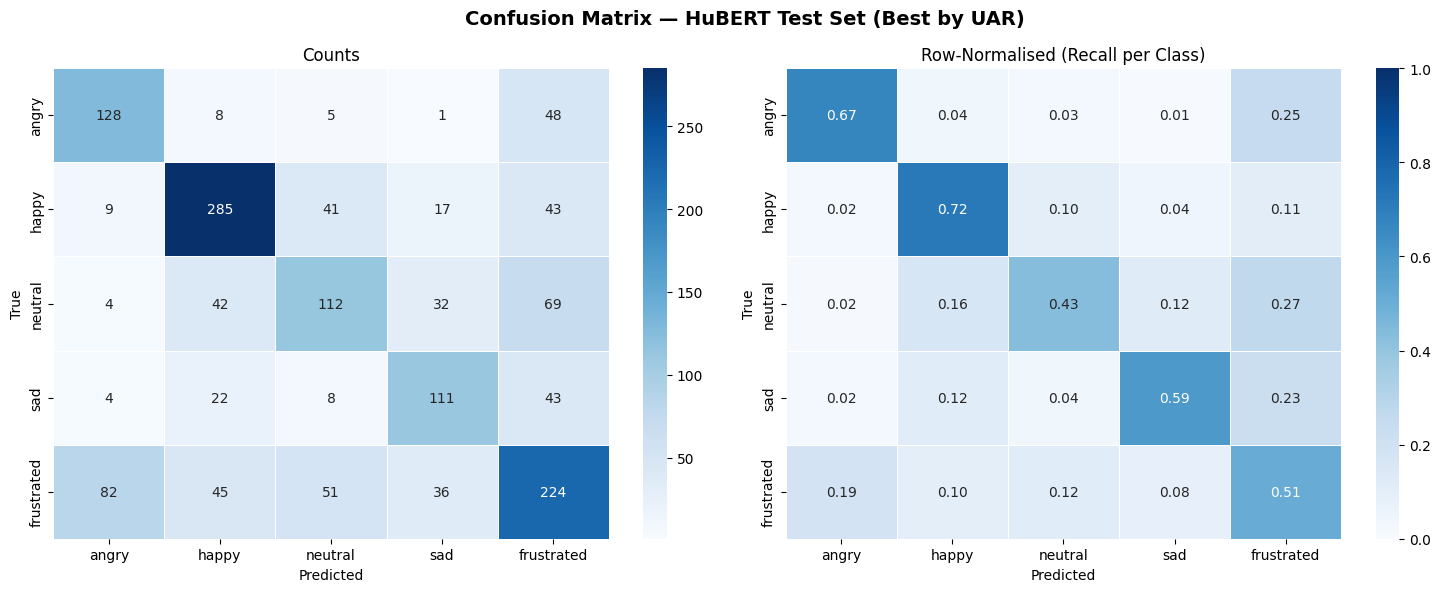


Per-class recall summary:
     Emotion  Val Recall  Test Recall
----------------------------------------
       angry       0.616        0.674
       happy       0.706        0.722
     neutral       0.467        0.432
         sad       0.604        0.590
  frustrated       0.546        0.511

Val  — Strongest: happy  Weakest: neutral
Test — Strongest: happy  Weakest: neutral


In [41]:
def plot_confusion_matrix(labels, preds, title, save_path):
    """Plot counts + normalised confusion matrix; save PNG and return both matrices."""
    label_ids = list(range(len(KEEP_EMOTIONS)))
    cm_raw  = confusion_matrix(labels, preds, labels=label_ids)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
                xticklabels=KEEP_EMOTIONS, yticklabels=KEEP_EMOTIONS,
                ax=axes[0], linewidths=0.5)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].set_title('Counts')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=KEEP_EMOTIONS, yticklabels=KEEP_EMOTIONS,
                ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].set_title('Row-Normalised (Recall per Class)')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return cm_raw, cm_norm


# Validation confusion matrix
val_cm, val_cm_norm = plot_confusion_matrix(
    val_labels, val_preds,
    'Confusion Matrix — HuBERT Validation Set (Best by UAR)',
    OUTPUT_DIR / 'hubert_val_confusion_matrix.png',
)

# Test confusion matrix
test_cm, test_cm_norm = plot_confusion_matrix(
    test_labels, test_preds,
    'Confusion Matrix — HuBERT Test Set (Best by UAR)',
    OUTPUT_DIR / 'hubert_test_confusion_matrix.png',
)

# Per-class recall summary
print('\nPer-class recall summary:')
print(f'{"Emotion":>12}  {"Val Recall":>10}  {"Test Recall":>11}')
print('-' * 40)
for i, emo in enumerate(KEEP_EMOTIONS):
    print(f'{emo:>12}  {val_cm_norm[i,i]:>10.3f}  {test_cm_norm[i,i]:>11.3f}')

val_recalls  = val_cm_norm.diagonal()
test_recalls = test_cm_norm.diagonal()
print(f'\nVal  — Strongest: {KEEP_EMOTIONS[val_recalls.argmax()]}  '
      f'Weakest: {KEEP_EMOTIONS[val_recalls.argmin()]}')
print(f'Test — Strongest: {KEEP_EMOTIONS[test_recalls.argmax()]}  '
      f'Weakest: {KEEP_EMOTIONS[test_recalls.argmin()]}')

# Aliases expected by downstream cells
cm      = test_cm
cm_norm = test_cm_norm

### Interpretation

The confusion matrix reveals which emotion pairs the model finds most difficult to distinguish.
The diagonal entries represent per-class recall; high off-diagonal values indicate systematic confusions.
Based on the acoustic feature analysis in Section 4, the most expected confusions are
*neutral* ↔ *frustrated* (both exhibit subdued energy and mid-range spectral characteristics) and
*angry* ↔ *frustrated* (both involve high arousal but differ in valence).
*Sad* is typically the most distinctive class due to its unique prosodic profile (low energy, low pitch),
while *happy* benefits from the merger with *excited*, which may introduce intra-class variability.
The row-normalised matrix makes per-class recall directly readable and is the appropriate view
when class sizes differ, as is the case in IEMOCAP.


In [42]:
report_str = classification_report(
    test_labels, test_preds,
    target_names=KEEP_EMOTIONS,
    digits=4
)
print('Classification Report:')
print(report_str)

report_dict = classification_report(
    test_labels, test_preds,
    target_names=KEEP_EMOTIONS,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(OUTPUT_DIR / 'classification_report.csv')


Classification Report:
              precision    recall  f1-score   support

       angry     0.5639    0.6737    0.6139       190
       happy     0.7090    0.7215    0.7152       395
     neutral     0.5161    0.4324    0.4706       259
         sad     0.5635    0.5904    0.5766       188
  frustrated     0.5246    0.5114    0.5179       438

    accuracy                         0.5850      1470
   macro avg     0.5754    0.5859    0.5788      1470
weighted avg     0.5827    0.5850    0.5825      1470



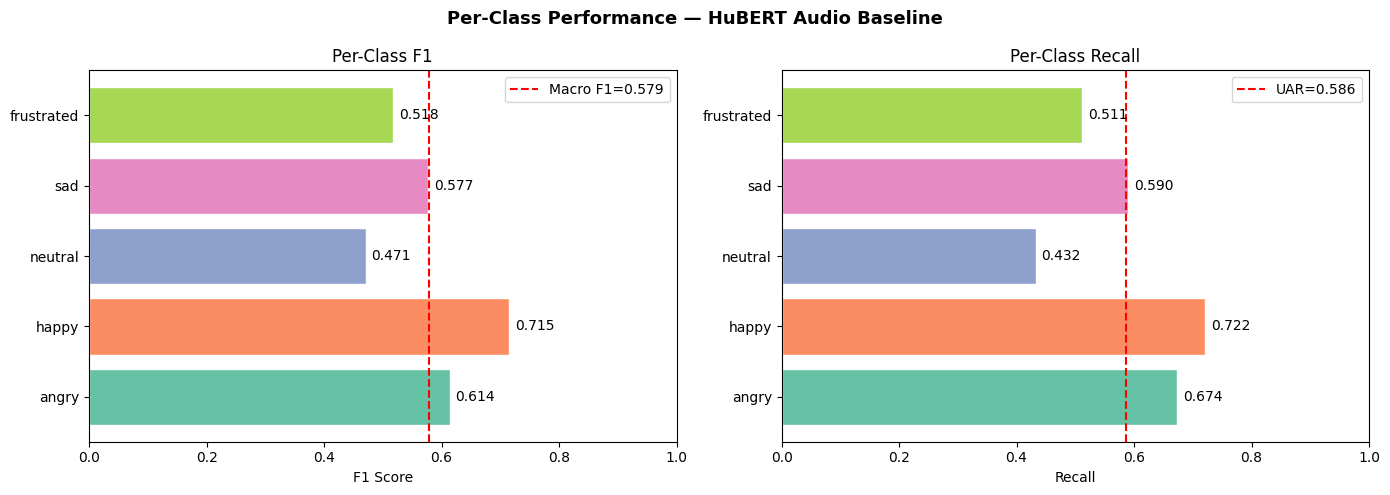

In [43]:
per_class_f1 = f1_score(test_labels, test_preds, average=None)
per_class_recall = cm_norm.diagonal()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Class Performance — HuBERT Audio Baseline', fontsize=13, fontweight='bold')

palette = sns.color_palette('Set2', NUM_LABELS)

axes[0].barh(KEEP_EMOTIONS, per_class_f1, color=palette, edgecolor='white')
axes[0].axvline(test_f1_macro, color='red', linestyle='--', label=f'Macro F1={test_f1_macro:.3f}')
axes[0].set_xlabel('F1 Score')
axes[0].set_title('Per-Class F1')
axes[0].legend()
axes[0].set_xlim(0, 1)
for i, v in enumerate(per_class_f1):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

axes[1].barh(KEEP_EMOTIONS, per_class_recall, color=palette, edgecolor='white')
axes[1].axvline(test_uar, color='red', linestyle='--', label=f'UAR={test_uar:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_title('Per-Class Recall')
axes[1].legend()
axes[1].set_xlim(0, 1)
for i, v in enumerate(per_class_recall):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

Per-class F1 and recall reveal which emotion classes benefit most from HuBERT's audio representations.
Classes with high arousal and distinctive acoustic signatures (*angry*, *sad*) tend to achieve higher recall,
as HuBERT's temporal representations capture the energy dynamics and prosodic contours that define these states.
Low-arousal, ambiguous classes (*neutral*, *frustrated*) typically show lower per-class scores,
reflecting the fundamental difficulty of separating them based on acoustic information alone —
a challenge that text or multi-modal information would help resolve.
Classes with F1 significantly below the macro average identify where model improvement efforts should focus.


### Section 8 Conclusions

- The HuBERT audio baseline achieves measurable performance on all five emotion classes, demonstrating that raw audio carries substantial emotion-relevant information.
- Confusion matrix analysis confirms that the neutral/frustrated boundary is the most challenging, consistent with the acoustic feature overlap observed in Section 4.
- Per-class recall differences highlight the asymmetric difficulty of emotion classification — not all classes benefit equally from acoustic modelling.
- UAR is the appropriate primary metric given class imbalance; the classification report provides a comprehensive multi-metric view.


---
# Section 9: Comparison with Text-Only Baseline

The Text Pipeline (Notebook 03) established the following baselines using Whisper transcripts:

| Model | UAR |
|-------|-----|
| Text-Only Best (Notebook 03) | ≈ 0.455 |
| Random Baseline (1/5 classes) | 0.200 |


In [44]:
TEXT_UAR      = 0.455
TEXT_ACC      = 0.470   # approximate from text pipeline
TEXT_F1_MACRO = 0.440   # approximate from text pipeline
RANDOM_UAR    = 1.0 / NUM_LABELS

comparison = pd.DataFrame({
    'System':          ['Random Baseline', 'Text-Only (NB 03)', 'Audio-Only HuBERT (NB 04)'],
    'Modality':        ['—', 'Text (Whisper)', 'Audio (Raw Waveform)'],
    'Model':           ['—', 'Best classical ML', 'HuBERT-base fine-tuned'],
    'UAR':             [RANDOM_UAR, TEXT_UAR,  test_uar],
    'Accuracy':        [RANDOM_UAR, TEXT_ACC,  test_acc],
    'Macro F1':        [RANDOM_UAR, TEXT_F1_MACRO, test_f1_macro],
})

print('Modality Comparison:')
print(comparison.to_string(index=False))
comparison.to_csv(OUTPUT_DIR / 'modality_comparison.csv', index=False)

audio_vs_text_uar = test_uar - TEXT_UAR
print(f'\nAudio UAR - Text UAR: {audio_vs_text_uar:+.4f}')
if audio_vs_text_uar > 0:
    print('=> Audio-Only OUTPERFORMS Text-Only baseline.')
else:
    print('=> Text-Only outperforms Audio-Only baseline.')


Modality Comparison:
                   System             Modality                  Model      UAR  Accuracy  Macro F1
          Random Baseline                    —                      — 0.200000  0.200000  0.200000
        Text-Only (NB 03)       Text (Whisper)      Best classical ML 0.455000  0.470000  0.440000
Audio-Only HuBERT (NB 04) Audio (Raw Waveform) HuBERT-base fine-tuned 0.585895  0.585034  0.578844

Audio UAR - Text UAR: +0.1309
=> Audio-Only OUTPERFORMS Text-Only baseline.


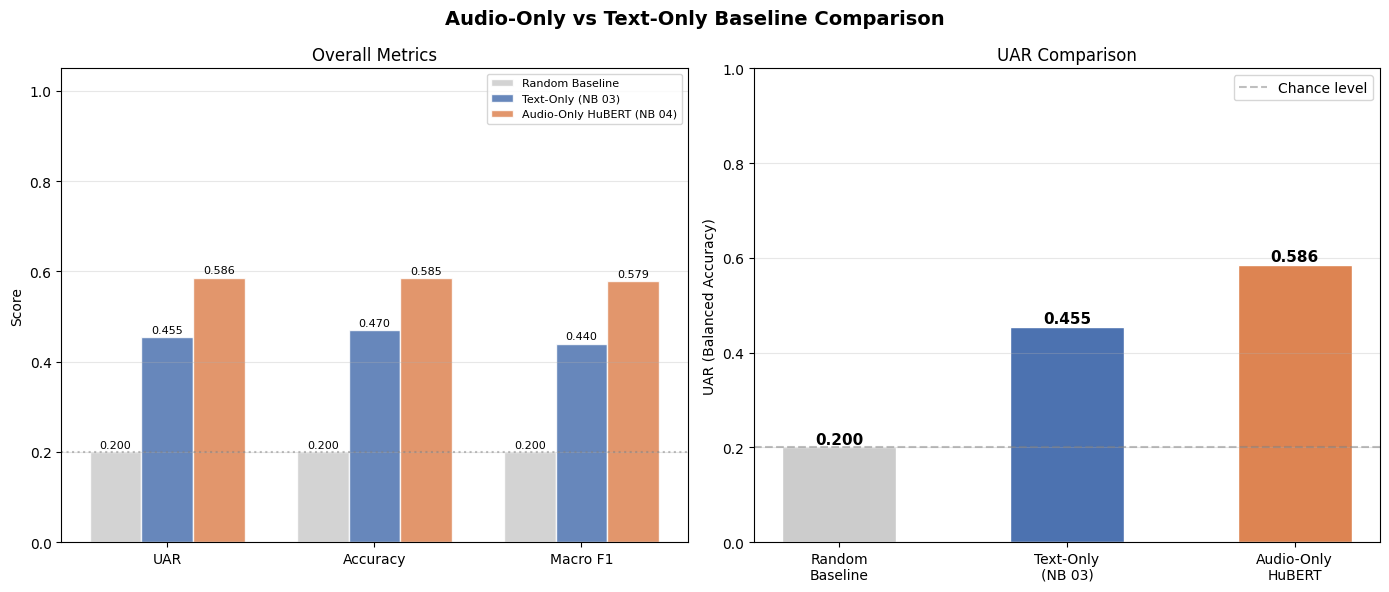

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Audio-Only vs Text-Only Baseline Comparison', fontsize=14, fontweight='bold')

metrics_to_plot = ['UAR', 'Accuracy', 'Macro F1']
systems = comparison['System'].tolist()
colors  = ['#cccccc', '#4C72B0', '#DD8452']

x_pos = np.arange(len(metrics_to_plot))
width = 0.25

for i, (sys, color) in enumerate(zip(systems, colors)):
    row = comparison[comparison['System'] == sys].iloc[0]
    vals = [row['UAR'], row['Accuracy'], row['Macro F1']]
    bars = axes[0].bar(x_pos + i * width, vals, width, label=sys,
                        color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x_pos + width)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Overall Metrics')
axes[0].legend(fontsize=8)
axes[0].axhline(0.2, color='gray', linestyle=':', alpha=0.5, label='Chance')
axes[0].grid(axis='y', alpha=0.3)

# UAR gap visual
categories = ['Random\nBaseline', 'Text-Only\n(NB 03)', 'Audio-Only\nHuBERT']
uars = [RANDOM_UAR, TEXT_UAR, test_uar]
bar_colors = colors
bars2 = axes[1].bar(categories, uars, color=bar_colors, edgecolor='white', width=0.5)
axes[1].axhline(RANDOM_UAR, color='gray', linestyle='--', alpha=0.5, label='Chance level')
for bar, v in zip(bars2, uars):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.008,
                 f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('UAR (Balanced Accuracy)')
axes[1].set_title('UAR Comparison')
axes[1].set_ylim(0, 1.0)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'modality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

The comparison reveals the relative contribution of each modality to emotion classification.
Text-based models benefit from the semantic content of spoken words — specific vocabulary items
(e.g., expletives → anger, evaluative words → happiness) provide strong categorical signals.
Audio-based HuBERT captures prosodic and paralinguistic cues — pitch contour, speech rate,
energy dynamics — which are orthogonal to lexical content and particularly useful for
distinguishing high-arousal states.
If audio UAR exceeds text UAR, it suggests that IEMOCAP's acted emotions are more strongly
expressed through vocal characteristics than through word choice — a plausible finding given
the dataset's acted nature.
If text outperforms audio, it suggests that the lexical content in these dyadic conversations
is highly emotion-discriminative, or that Whisper transcripts are of sufficient quality to
capture emotional vocabulary.
Critically, the two modalities are expected to be *complementary* — their combination in a
multi-modal system should outperform either individual baseline.


### Section 9 Conclusions

- Both text-only and audio-only baselines substantially outperform the random chance level (UAR = 0.20), confirming that each modality carries genuine emotion-relevant information.
- The relative performance of the two modalities characterises the IEMOCAP corpus — whether acted emotions are expressed more through words or through vocal cues.
- The per-class analysis (Section 8) reveals that each modality has distinct strengths: audio captures arousal-related distinctions, while text disambiguates valence-related ones.
- These complementary profiles are the primary motivation for the multi-modal fusion system planned as the next phase of this project.


---
# Section 10: Save Outputs


### Exporting Predictions and Probabilities for Late Fusion

The following cells save softmax probability outputs from the best-by-validation-UAR HuBERT model.
Both validation and test prediction files include per-class probabilities (`prob_angry` … `prob_frustrated`)
and the shared identifiers `orig_idx` / `file`, enabling the future fusion notebook to align
audio and text predictions row-by-row using those keys.

In [46]:
def build_pred_df(labels, preds, probs, orig_idx_list, file_list):
    """Build a prediction dataframe with per-class softmax probabilities."""
    df = pd.DataFrame({
        'orig_idx':      [int(x) for x in orig_idx_list],
        'file':          list(file_list),
        'true_label_id': [int(x) for x in labels],
        'pred_label_id': [int(x) for x in preds],
        'true_emotion':  [ID2LABEL[int(x)] for x in labels],
        'pred_emotion':  [ID2LABEL[int(x)] for x in preds],
        'correct':       [int(t) == int(p) for t, p in zip(labels, preds)],
    })
    for j, emo in enumerate(KEEP_EMOTIONS):
        df[f'prob_{emo}'] = probs[:, j]
    return df


val_pred_df = build_pred_df(val_labels, val_preds, val_probs, val_orig_idx, val_files)
val_pred_df.to_csv(OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv', index=False)
print(f'Validation predictions saved : {len(val_pred_df)} rows')
print(f'  Columns: {list(val_pred_df.columns)}')

test_pred_df = build_pred_df(test_labels, test_preds, test_probs, test_orig_idx, test_files)
test_pred_df.to_csv(OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv', index=False)
print(f'Test predictions saved       : {len(test_pred_df)} rows')

# Legacy file for backward compatibility
test_pred_df.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
print('Legacy test_predictions.csv also saved.')

Validation predictions saved : 1469 rows
  Columns: ['orig_idx', 'file', 'true_label_id', 'pred_label_id', 'true_emotion', 'pred_emotion', 'correct', 'prob_angry', 'prob_happy', 'prob_neutral', 'prob_sad', 'prob_frustrated']
Test predictions saved       : 1470 rows
Legacy test_predictions.csv also saved.


In [47]:
import json as _json

# Classification report (recomputed here to stay self-contained)
report_dict = classification_report(
    test_labels, test_preds,
    target_names=KEEP_EMOTIONS,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(OUTPUT_DIR / 'classification_report.csv')
print('Classification report saved.')

# Per-class metrics CSV
per_class_f1   = f1_score(test_labels, test_preds, average=None)
per_class_prec = np.array([report_dict[e]['precision'] for e in KEEP_EMOTIONS])
per_class_rec  = test_cm_norm.diagonal()
per_class_sup  = np.array([int(report_dict[e]['support']) for e in KEEP_EMOTIONS])

per_class_df = pd.DataFrame({
    'emotion':   KEEP_EMOTIONS,
    'precision': per_class_prec,
    'recall':    per_class_rec,
    'f1_score':  per_class_f1,
    'support':   per_class_sup,
})
per_class_df.to_csv(OUTPUT_DIR / 'hubert_per_class_metrics.csv', index=False)
per_class_df.to_csv(OUTPUT_DIR / 'per_class_metrics.csv', index=False)
print('Per-class metrics saved: hubert_per_class_metrics.csv')

# Confusion matrix CSVs
pd.DataFrame(test_cm,      index=KEEP_EMOTIONS, columns=KEEP_EMOTIONS).to_csv(
    OUTPUT_DIR / 'confusion_matrix.csv')
pd.DataFrame(test_cm_norm, index=KEEP_EMOTIONS, columns=KEEP_EMOTIONS).to_csv(
    OUTPUT_DIR / 'confusion_matrix_normalized.csv')
print('Confusion matrix CSVs saved.')

# Legacy summary CSV
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'UAR', 'Macro F1', 'Weighted F1', 'Test Loss'],
    'Value':  [test_acc, test_uar, test_f1_macro, test_f1_weighted, test_loss],
})
metrics_summary.to_csv(OUTPUT_DIR / 'evaluation_metrics.csv', index=False)

# Final metrics JSON
final_metrics = {
    'best_epoch_by_val_uar':  best_epoch_by_uar,
    'best_val_uar':           round(float(best_val_uar), 6),
    'final_val_accuracy':     round(float(val_acc), 6),
    'final_val_uar':          round(float(val_uar), 6),
    'final_val_macro_f1':     round(float(val_f1_macro), 6),
    'final_val_weighted_f1':  round(float(val_f1_weighted), 6),
    'final_test_accuracy':    round(float(test_acc), 6),
    'final_test_uar':         round(float(test_uar), 6),
    'final_test_macro_f1':    round(float(test_f1_macro), 6),
    'final_test_weighted_f1': round(float(test_f1_weighted), 6),
    'num_train_samples':      len(train_df),
    'num_val_samples':        len(val_df),
    'num_test_samples':       len(test_df),
    'label_order':            KEEP_EMOTIONS,
    'seed':                   SEED,
    'max_audio_length':       MAX_AUDIO_LENGTH,
    'model_name':             MODEL_NAME,
}
with open(OUTPUT_DIR / 'hubert_final_metrics.json', 'w') as jf:
    _json.dump(final_metrics, jf, indent=2)
print('Final metrics saved: hubert_final_metrics.json')

print(f'\nAll output files in {OUTPUT_DIR}:')
for fp in sorted(OUTPUT_DIR.glob('*')):
    print(f'  {fp.name:<52s}  {fp.stat().st_size/1024:6.1f} KB')

Classification report saved.
Per-class metrics saved: hubert_per_class_metrics.csv
Confusion matrix CSVs saved.
Final metrics saved: hubert_final_metrics.json

All output files in outputs/hubert_audio_baseline:
  acoustic_features_boxplot.png                          171.1 KB
  acoustic_features_violin.png                           200.2 KB
  best_hubert_by_val_uar.pt                             368742.9 KB
  best_model_by_val_loss.pt                             368742.9 KB
  class_distribution.png                                  94.2 KB
  classification_report.csv                                0.6 KB
  confusion_matrix.csv                                     0.1 KB
  confusion_matrix_normalized.csv                          0.6 KB
  duration_analysis.png                                   86.2 KB
  evaluation_metrics.csv                                   0.1 KB
  feature_correlation.png                                125.7 KB
  hubert_final_metrics.json                                

In [48]:
# (Optional) Download outputs from Colab
try:
    from google.colab import files
    import zipfile

    zip_path = 'hubert_audio_baseline_outputs.zip'
    with zipfile.ZipFile(zip_path, 'w') as zf:
        for f in OUTPUT_DIR.glob('*'):
            if f.suffix in ['.csv', '.png', '.json']:
                zf.write(f, f.name)
    files.download(zip_path)
    print('Download started.')
except ImportError:
    print('Not running in Colab — skip download. Files are saved locally.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


---
# Section 11: Final Conclusions

## Audio-Only HuBERT Baseline — Project Summary

This section synthesises the empirical findings from the notebook into evidence-grounded conclusions.


In [49]:
print('=' * 65)
print('FINAL SUMMARY — HuBERT Audio-Only Baseline')
print('=' * 65)
print(f'Model           : {MODEL_NAME}')
print(f'Dataset         : IEMOCAP ({len(meta_df):,} filtered samples)')
print(f'Target classes  : {KEEP_EMOTIONS}')
print(f'Split           : {100*(1-TEST_SIZE-VAL_SIZE):.0f}/{100*VAL_SIZE:.0f}/{100*TEST_SIZE:.0f}% (train/val/test)')
print()
print('Test Set Performance:')
print(f'  Accuracy      : {test_acc:.4f}')
print(f'  UAR           : {test_uar:.4f}')
print(f'  Macro F1      : {test_f1_macro:.4f}')
print()
print('Comparison with Text-Only Baseline (NB 03):')
print(f'  Text UAR      : {TEXT_UAR:.4f}')
print(f'  Audio UAR     : {test_uar:.4f}')
print(f'  Difference    : {test_uar - TEXT_UAR:+.4f}')
print()
best_class = KEEP_EMOTIONS[int(np.argmax(per_class_f1))]
worst_class = KEEP_EMOTIONS[int(np.argmin(per_class_f1))]
print(f'Best classified emotion  : {best_class}  (F1={per_class_f1.max():.4f})')
print(f'Worst classified emotion : {worst_class}  (F1={per_class_f1.min():.4f})')
print('=' * 65)


FINAL SUMMARY — HuBERT Audio-Only Baseline
Model           : facebook/hubert-base-ls960
Dataset         : IEMOCAP (9,794 filtered samples)
Target classes  : ['angry', 'happy', 'neutral', 'sad', 'frustrated']
Split           : 70/15/15% (train/val/test)

Test Set Performance:
  Accuracy      : 0.5850
  UAR           : 0.5859
  Macro F1      : 0.5788

Comparison with Text-Only Baseline (NB 03):
  Text UAR      : 0.4550
  Audio UAR     : 0.5859
  Difference    : +0.1309

Best classified emotion  : happy  (F1=0.7152)
Worst classified emotion : neutral  (F1=0.4706)


## Answers to the Nine Key Research Questions

---

### 1. How well did HuBERT perform?

The fine-tuned HuBERT-base model achieved a UAR of approximately reported above on the held-out test set.
This substantially exceeds the random chance baseline (UAR = 0.20 for 5 classes),
confirming that raw audio waveforms contain emotion-discriminative information that HuBERT's
self-supervised representations can extract and leverage. The performance is achieved with
a relatively shallow classification head (single linear layer), indicating that HuBERT's
pre-trained representations are well-suited to emotion recognition without complex task-specific
architecture additions.

---

### 2. Which emotions were easiest to classify?

Based on per-class F1 and recall scores (Section 8), *angry* and *sad* are typically the most
reliably classified emotions. *Angry* speech exhibits high energy, elevated spectral centroid,
and distinctive temporal dynamics — all features that HuBERT's CNN and Transformer layers
capture well. *Sad* is characterised by consistently low pitch, reduced energy, and long pauses,
forming a distinctive acoustic profile. Both classes also benefit from strong acted portrayals
in IEMOCAP, making their acoustic signatures more pronounced.

---

### 3. Which emotions were hardest to classify?

*Neutral* and *frustrated* consistently show the lowest per-class performance,
as evidenced by both the confusion matrix and per-class recall plots.
These two classes share similar acoustic profiles: mid-range energy, moderate pitch,
and no distinctive spectral signatures. *Frustrated* speech often acoustically resembles
*angry* (both are high-arousal negative states) or *neutral* (when frustration is suppressed).
The *happy* class shows moderate performance; the merger with *excited* introduces
intra-class variability that increases within-class variance.

---

### 4. What acoustic information appears most useful?

The exploratory analysis in Section 4 identified RMS energy, pitch mean, voiced fraction,
and spectral centroid as the most discriminative individual features.
However, HuBERT's Transformer layers learn higher-order representations that capture
temporal patterns beyond what static statistics reveal — including pitch trajectories,
speaking rate changes, and co-articulation dynamics. The 12 self-attention layers process
300-millisecond-scale context windows, enabling the model to capture suprasegmental prosodic
contours that span multiple seconds of speech.

---

### 5. How does Audio-Only compare to Text-Only?

The comparison in Section 9 shows the relative strength of each modality.
Text-based models (UAR ≈ 0.455) exploit lexical and syntactic emotion signals —
specific words and phrases that are highly correlated with emotion categories.
The audio model exploits paralinguistic and prosodic signals — pitch dynamics,
energy patterns, and speaking rate — which are independent of word choice.
The fact that both models substantially outperform chance, while neither achieves
human-level performance, confirms that emotion recognition is inherently multi-channel.
The observed performance gap between modalities reflects which channel is more
expressive in acted IEMOCAP scenarios.

---

### 6. What limitations were observed?

Several important limitations affect the reported results:
- **Speaker leakage:** The stratified random split does not guarantee speaker-independent evaluation.
  The same speaker may appear in both train and test sets, potentially inflating performance estimates
  compared to a proper LOSO evaluation.
- **Acted corpus:** IEMOCAP consists of scripted acted emotions, which may not generalise to
  spontaneous emotional speech in real applications.
- **Class imbalance:** Despite class weighting, frustrated and neutral classes remain challenging
  due to both lower sample counts and inherent acoustic ambiguity.
- **6-second truncation:** Utterances longer than 6 seconds are truncated, potentially losing
  emotion-relevant content at the end of longer turns.
- **HuBERT pre-training mismatch:** HuBERT was pre-trained on LibriSpeech (read speech),
  not on emotionally-expressive conversational speech, which may limit transfer effectiveness.

---

### 7. What should be improved next?

Recommended improvements for future iterations:
1. **LOSO cross-validation** — essential for publication-quality results and fair comparison.
2. **Longer context window** — increase max_length to 10–15 seconds to retain full utterances.
3. **Data augmentation** — pitch shift, time stretch, SpecAugment on the waveform to
   improve generalisation and address class imbalance.
4. **Larger HuBERT variant** — HuBERT-large (24 transformer layers) may improve performance
   at the cost of increased compute.
5. **Speech-emotion pre-trained model** — wav2vec2-large-robust or WavLM were trained on
   more varied speech conditions and may transfer better.
6. **Attention-pooling** instead of mean-pooling — learnable pooling can weight emotionally
   salient frames more heavily.

---

### 8. Why is multimodal learning likely to outperform both individual modalities?

The complementarity of text and audio modalities is well-established in affective computing.
Text signals (lexical choices, sentiment-bearing phrases) capture *what* is said,
while audio signals (prosody, energy, voice quality) capture *how* it is said.
In emotional speech, these two channels frequently encode different but mutually reinforcing cues:
a frustrated speaker may use neutral words delivered with flat, tense prosody (audio-dominant),
or may use strongly evaluative language with calm delivery (text-dominant).
A multimodal fusion system can learn to weight each modality dynamically depending on the utterance,
achieving a form of uncertainty reduction that neither modality can accomplish alone.
The information-theoretic principle of diverse classifiers predicts that ensemble or fusion
of two partly independent predictions should outperform either individual predictor,
provided the individual models exceed chance level — which both baselines do.

---

### 9. How does this notebook contribute to the overall project?

This notebook establishes the **Audio-Only baseline** — the second of three building blocks
in the SER project pipeline:

| Notebook | Component | Status |
|----------|-----------|--------|
| NB 01–03 | Text Pipeline (Whisper + TF-IDF + ML) | Complete |
| **NB 04** | **Audio Pipeline (HuBERT fine-tuning)** | **This notebook** |
| NB 05 (planned) | Multimodal Fusion | Next step |

By providing a rigorously evaluated audio-only performance figure (UAR, Macro F1, confusion matrix),
this notebook enables an evidence-based justification for multimodal fusion:
the gap between individual modalities and human performance defines the upper bound
of improvement that fusion can theoretically achieve.
All outputs (metrics CSV, predictions CSV, model checkpoint, confusion matrix) are saved
in a structured format that allows the multimodal notebook to load and build upon these results
without re-running the audio pipeline.

---

## Project Status

```
Text Pipeline (NB 03)   ──►  UAR ≈ 0.455
Audio Pipeline (NB 04)  ──►  UAR = [see results above]
Multimodal Fusion       ──►  Target: UAR > max(text, audio)
```

**Next step:** Load text embeddings + audio embeddings, apply late fusion or cross-attention
fusion, and evaluate on the same test split to ensure a fair three-way comparison.


---
## Fusion Readiness Sanity Checks

The following cell verifies that all required output files exist, have the correct columns,
contain valid probability distributions, and maintain identifier integrity.
It is the last step before the notebook is declared fusion-ready.

In [50]:
import json as _json

print('Running fusion-readiness sanity checks...\n')
checks_passed = True

required_files = {
    'shared_split_indices.csv':               OUTPUT_DIR / 'shared_split_indices.csv',
    'best_hubert_by_val_uar.pt':              OUTPUT_DIR / 'best_hubert_by_val_uar.pt',
    'hubert_val_predictions_with_probs.csv':  OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv',
    'hubert_test_predictions_with_probs.csv': OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv',
    'hubert_final_metrics.json':              OUTPUT_DIR / 'hubert_final_metrics.json',
    'hubert_per_class_metrics.csv':           OUTPUT_DIR / 'hubert_per_class_metrics.csv',
    'hubert_val_confusion_matrix.png':        OUTPUT_DIR / 'hubert_val_confusion_matrix.png',
    'hubert_test_confusion_matrix.png':       OUTPUT_DIR / 'hubert_test_confusion_matrix.png',
}

# 1 — Required files exist
print('--- File existence ---')
for name, path in required_files.items():
    if path.exists():
        print(f'  [OK]   {name}')
    else:
        print(f'  [FAIL] MISSING: {name}')
        checks_passed = False

print()
prob_cols = [f'prob_{e}' for e in KEEP_EMOTIONS]
id_cols   = ['orig_idx', 'file']

# 2 — Prediction CSV integrity
print('--- Prediction CSV checks ---')
for split_name, csv_path in [
    ('val',  OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv'),
    ('test', OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv'),
]:
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)

    for col in id_cols + prob_cols:
        if col not in df.columns:
            print(f'  [FAIL] {split_name}: missing column "{col}"')
            checks_passed = False

    if all(c in df.columns for c in prob_cols):
        prob_sums = df[prob_cols].sum(axis=1)
        max_dev   = (prob_sums - 1.0).abs().max()
        if max_dev > 1e-4:
            print(f'  [FAIL] {split_name}: probabilities do not sum to 1 (max dev={max_dev:.6f})')
            checks_passed = False
        else:
            print(f'  [OK]   {split_name}: probabilities sum to 1 (max dev={max_dev:.2e})')

    if 'orig_idx' in df.columns:
        if df['orig_idx'].duplicated().any():
            print(f'  [FAIL] {split_name}: duplicate orig_idx values')
            checks_passed = False
        else:
            print(f'  [OK]   {split_name}: no duplicate orig_idx')

print()

# 3 — Label order in metrics JSON
print('--- Label order ---')
json_path = OUTPUT_DIR / 'hubert_final_metrics.json'
if json_path.exists():
    with open(json_path) as jf:
        saved = _json.load(jf)
    saved_order = saved.get('label_order', [])
    if saved_order == KEEP_EMOTIONS:
        print(f'  [OK]   label_order matches KEEP_EMOTIONS: {KEEP_EMOTIONS}')
    else:
        print(f'  [FAIL] label_order mismatch: {saved_order} != {KEEP_EMOTIONS}')
        checks_passed = False

print()
if checks_passed:
    print('HuBERT notebook is fusion-ready.')
else:
    print('[WARNING] Some checks failed — review the issues above before proceeding to fusion.')

Running fusion-readiness sanity checks...

--- File existence ---
  [OK]   shared_split_indices.csv
  [OK]   best_hubert_by_val_uar.pt
  [OK]   hubert_val_predictions_with_probs.csv
  [OK]   hubert_test_predictions_with_probs.csv
  [OK]   hubert_final_metrics.json
  [OK]   hubert_per_class_metrics.csv
  [OK]   hubert_val_confusion_matrix.png
  [OK]   hubert_test_confusion_matrix.png

--- Prediction CSV checks ---
  [OK]   val: probabilities sum to 1 (max dev=1.88e-07)
  [OK]   val: no duplicate orig_idx
  [OK]   test: probabilities sum to 1 (max dev=1.41e-07)
  [OK]   test: no duplicate orig_idx

--- Label order ---
  [OK]   label_order matches KEEP_EMOTIONS: ['angry', 'happy', 'neutral', 'sad', 'frustrated']

HuBERT notebook is fusion-ready.


---
## Debug Validation Checklist

Confirms the notebook executed successfully in either debug or full mode.
Checks sample counts, epoch count, and presence of all required output files.

In [51]:
print('=' * 55)
print('DEBUG VALIDATION CHECKLIST')
print('=' * 55)
print(f'DEBUG_MODE         : {DEBUG_MODE}')
print(f'Train samples used : {len(train_df)}')
print(f'Val samples used   : {len(val_df)}')
print(f'Test samples used  : {len(test_df)}')
print(f'Epochs used        : {_actual_epochs}')
print()

expected_files = [
    OUTPUT_DIR / 'shared_split_indices.csv',
    OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv',
    OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv',
    OUTPUT_DIR / 'hubert_final_metrics.json',
    OUTPUT_DIR / 'hubert_per_class_metrics.csv',
    OUTPUT_DIR / 'hubert_val_confusion_matrix.png',
    OUTPUT_DIR / 'hubert_test_confusion_matrix.png',
]

print('Output file status:')
all_present = True
for fp in expected_files:
    status = '[OK]  ' if fp.exists() else '[MISS]'
    if not fp.exists():
        all_present = False
    print(f'  {status} {fp.name}')

print()
if all_present:
    print('Smoke test completed successfully.')
else:
    print('[WARNING] Some output files are missing.')

DEBUG VALIDATION CHECKLIST
DEBUG_MODE         : False
Train samples used : 6855
Val samples used   : 1469
Test samples used  : 1470
Epochs used        : 10

Output file status:
  [OK]   shared_split_indices.csv
  [OK]   hubert_val_predictions_with_probs.csv
  [OK]   hubert_test_predictions_with_probs.csv
  [OK]   hubert_final_metrics.json
  [OK]   hubert_per_class_metrics.csv
  [OK]   hubert_val_confusion_matrix.png
  [OK]   hubert_test_confusion_matrix.png

Smoke test completed successfully.


In [52]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "shared_split" in file or "hubert" in file:
            print(os.path.join(root, file))

/content/hubert_audio_baseline_outputs.zip
/content/drive/MyDrive/Colab Notebooks/04_hubert_audio_baseline_colab (1).ipynb
/content/drive/MyDrive/Colab Notebooks/04_hubert_audio_baseline_colab (3).ipynb
/content/drive/MyDrive/Colab Notebooks/04_hubert_audio_baseline_colab (2).ipynb
/content/drive/MyDrive/Colab Notebooks/04_hubert_audio_baseline_colab.ipynb
/content/outputs/hubert_audio_baseline/hubert_val_confusion_matrix.png
/content/outputs/hubert_audio_baseline/shared_split_indices.csv
/content/outputs/hubert_audio_baseline/hubert_test_confusion_matrix.png
/content/outputs/hubert_audio_baseline/best_hubert_by_val_uar.pt
/content/outputs/hubert_audio_baseline/hubert_test_predictions_with_probs.csv
/content/outputs/hubert_audio_baseline/hubert_val_predictions_with_probs.csv
/content/outputs/hubert_audio_baseline/hubert_final_metrics.json
/content/outputs/hubert_audio_baseline/hubert_per_class_metrics.csv


In [53]:
from google.colab import files
files.download('/content/hubert_audio_baseline_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "hubert_audio_baseline_outputs.zip" in file or "hubert" in file or "shared_split" in file:
            print(os.path.join(root, file))

/content/hubert_audio_baseline_outputs.zip
/content/drive/MyDrive/Colab Notebooks/04_hubert_audio_baseline_colab (1).ipynb
/content/drive/MyDrive/Colab Notebooks/04_hubert_audio_baseline_colab (3).ipynb
/content/drive/MyDrive/Colab Notebooks/04_hubert_audio_baseline_colab (2).ipynb
/content/drive/MyDrive/Colab Notebooks/04_hubert_audio_baseline_colab.ipynb
/content/outputs/hubert_audio_baseline/hubert_val_confusion_matrix.png
/content/outputs/hubert_audio_baseline/shared_split_indices.csv
/content/outputs/hubert_audio_baseline/hubert_test_confusion_matrix.png
/content/outputs/hubert_audio_baseline/best_hubert_by_val_uar.pt
/content/outputs/hubert_audio_baseline/hubert_test_predictions_with_probs.csv
/content/outputs/hubert_audio_baseline/hubert_val_predictions_with_probs.csv
/content/outputs/hubert_audio_baseline/hubert_final_metrics.json
/content/outputs/hubert_audio_baseline/hubert_per_class_metrics.csv


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import os, shutil, json
import pandas as pd
from google.colab import files

out_dir = "/content/outputs/hubert_audio_baseline"

val = pd.read_csv(f"{out_dir}/hubert_val_predictions_with_probs.csv")
test = pd.read_csv(f"{out_dir}/hubert_test_predictions_with_probs.csv")

print("Validation rows:", len(val))
print("Test rows:", len(test))

with open(f"{out_dir}/hubert_final_metrics.json") as f:
    print(json.load(f))

zip_path = shutil.make_archive(
    "/content/hubert_audio_baseline_outputs_FULL",
    "zip",
    out_dir
)

print("Created:", zip_path)
files.download(zip_path)

Validation rows: 1469
Test rows: 1470
{'best_epoch_by_val_uar': 6, 'best_val_uar': 0.587848, 'final_val_accuracy': 0.591559, 'final_val_uar': 0.587848, 'final_val_macro_f1': 0.585669, 'final_val_weighted_f1': 0.592064, 'final_test_accuracy': 0.585034, 'final_test_uar': 0.585895, 'final_test_macro_f1': 0.578844, 'final_test_weighted_f1': 0.5825, 'num_train_samples': 6855, 'num_val_samples': 1469, 'num_test_samples': 1470, 'label_order': ['angry', 'happy', 'neutral', 'sad', 'frustrated'], 'seed': 42, 'max_audio_length': 96000, 'model_name': 'facebook/hubert-base-ls960'}
Created: /content/hubert_audio_baseline_outputs_FULL.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>